# **Multiple Linear Regression: Bike Sharing Demand**

# **Problem Statement**

Urban bike-sharing programs play a critical role in improving last-mile connectivity and promoting sustainable transportation. However, unpredictable demand can lead to bike shortages during peak hours and underutilized inventory during low-demand periods.

To operate efficiently, bike-sharing providers need accurate demand forecasts that help ensure optimal bike availability while minimizing operational inefficiencies.

This project aims to analyze historical rental data and predict hourly bike demand based on environmental and temporal factors.

# **Objective**

- Forecast hourly bike rental demand.
- Identify key factors influencing usage patterns.
- Understand seasonal and weather-based demand variations.
- Support fleet optimization and resource allocation.
- Enable data-driven operational planning

# **Dataset Description**

**1. instant:** record index

**2. dteday:** date

**3. season:** season (1:spring, 2:summer, 3:fall, 4:winter)

**4. yr:** year (0: 2011, 1:2012)

**5. mnth:** month ( 1 to 12)

**6. hr:** hour (0 to 23)

**7. holiday:** weather day is holiday or not

**8. weekday:** day of the week

**9. workingday:** if day is neither weekend nor holiday is 1, otherwise is 0.

**10. weathersit:** **1:** Clear, Few clouds, Partly cloudy, Partly cloudy. **2:** Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist. **3:** Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds. **4:** Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

**11. temp:** Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)

**12. atemp:** Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)

**13. hum:** Normalized humidity. The values are divided to 100 (max)

**14. windspeed:** Normalized wind speed. The values are divided to 67 (max)

**15. casual:** count of casual users

**16. registered:** count of registered users

**17. cnt:** count of total rental bikes including both casual and registered **(Target Variable)**

# **Day Data:**

# **Part A: Data Analysis**

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [2]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Print the last 5 rows
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [4]:
# Print the shape of the dataframe
df.shape

(731, 16)

In [5]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
# Data type of the attributes of the dataframe
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [7]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [9]:
df.keys()

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [10]:
df.nunique()

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


### **The shape of the dataset is (731,16). 731 unique values in the instant/dteday column indicates that each row is a unique entry for Bike Sharing.**

# **Part B: Data Preprocessing**

In [11]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
instant,0,0.0
dteday,0,0.0
season,0,0.0
yr,0,0.0
mnth,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temp,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

In [13]:
# Rename the features for better readability
df.rename(columns = {'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'weathersit': 'weather', 'cnt': 'count'}, inplace = True)
df.head()

,instant,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
# Drop the redundant features
# df = df.drop(['instant', 'atemp', 'hum', 'windspeed'], axis = 1)
df = df.drop(['instant', 'year', 'month'], axis = 1)
df.head()

,date,season,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,2011-01-01,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [15]:
df['date'] = df['date'].astype('datetime64[ns]')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df.drop('date', axis = 1)
df.head()

,season,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count,year,month
0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011,1
1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011,1
2,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011,1
3,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011,1
4,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011,1


In [16]:
value_counts_cols = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weather']

rows = []

for col in value_counts_cols:
    vc = df[col].value_counts().reset_index()
    vc.columns = ['value', 'count']
    rows.append(vc)

value_counts_df = pd.concat(rows, keys = value_counts_cols)
value_counts_df

value  count
season     0       3    188
           1       2    184
           2       1    181
           3       4    178
year       0    2012    366
           1    2011    365
month      0       1     62
           1       3     62
           2       7     62
           3       5     62
           4      12     62
           5      10     62
           6       8     62
           7       4     60
           8       9     60
           9       6     60
           10     11     60
           11      2     57
holiday    0       0    710
           1       1     21
weekday    0       6    105
           1       0    105
           2       1    105
           3       2    104
           4       3    104
           5       4    104
           6       5    104
workingday 0       1    500
           1       0    231
weather    0       1    463
           1       2    247
           2       3     21

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   holiday     731 non-null    int64  
 2   weekday     731 non-null    int64  
 3   workingday  731 non-null    int64  
 4   weather     731 non-null    int64  
 5   temp        731 non-null    float64
 6   atemp       731 non-null    float64
 7   hum         731 non-null    float64
 8   windspeed   731 non-null    float64
 9   casual      731 non-null    int64  
 10  registered  731 non-null    int64  
 11  count       731 non-null    int64  
 12  year        731 non-null    int32  
 13  month       731 non-null    int32  
dtypes: float64(4), int32(2), int64(8)
memory usage: 74.4 KB


# **Part C: Exploratory Data Analysis**

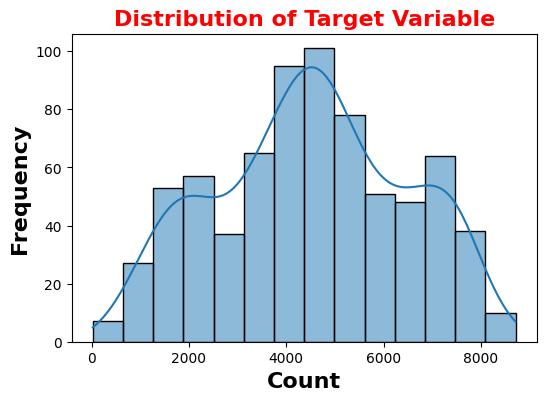

In [18]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.histplot(x = df['count'], kde = True)
plt.title('Distribution of Target Variable', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('Count', fontsize = 16, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 16, fontweight = 'bold')
plt.show()

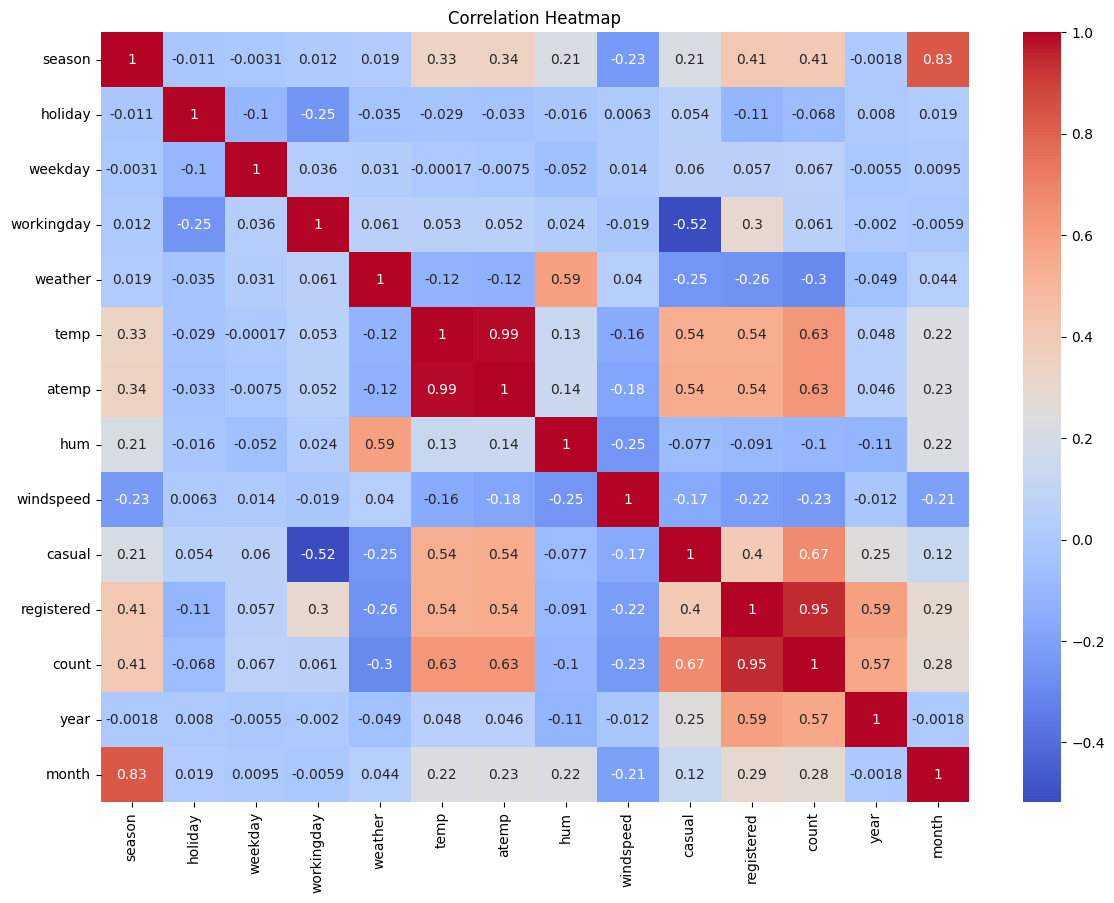

In [19]:
# Heatmap for correlation
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- **High multicollinearity** exists between temp and atemp (corr ≈ 0.99) and between season and month (corr ≈ 0.83), suggesting one from each pair can be dropped in simple models.

- **Strongest predictors** of count are temp/atemp (≈ 0.63), year (≈ 0.57–0.59), and weather-related features (weathersit ≈ -0.3, windspeed ≈ -0.23, humidity weak negative).

- casual (≈ 0.67) and registered (≈ 0.95) show very **high correlation** with count as they are direct components → must be excluded to prevent leakage.

- **Other features** like holiday, weekday, and workingday have mostly weak correlations with the target and other variables, but remain useful in combination with regularization.

## **Drop:**

✅ atemp

✅ casual

✅ registered

## **Keep:**

✅ month

✅ season

In [20]:
# Drop highly correlated feature atemp while keeping temp and redundant features of casual and registered
df = df.drop(['atemp', 'casual', 'registered'], axis = 1)
df.head()

,season,holiday,weekday,workingday,weather,temp,hum,windspeed,count,year,month
0,1,0,6,0,2,0.344167,0.805833,0.160446,985,2011,1
1,1,0,0,0,2,0.363478,0.696087,0.248539,801,2011,1
2,1,0,1,1,1,0.196364,0.437273,0.248309,1349,2011,1
3,1,0,2,1,1,0.200000,0.590435,0.160296,1562,2011,1
4,1,0,3,1,1,0.226957,0.436957,0.186900,1600,2011,1


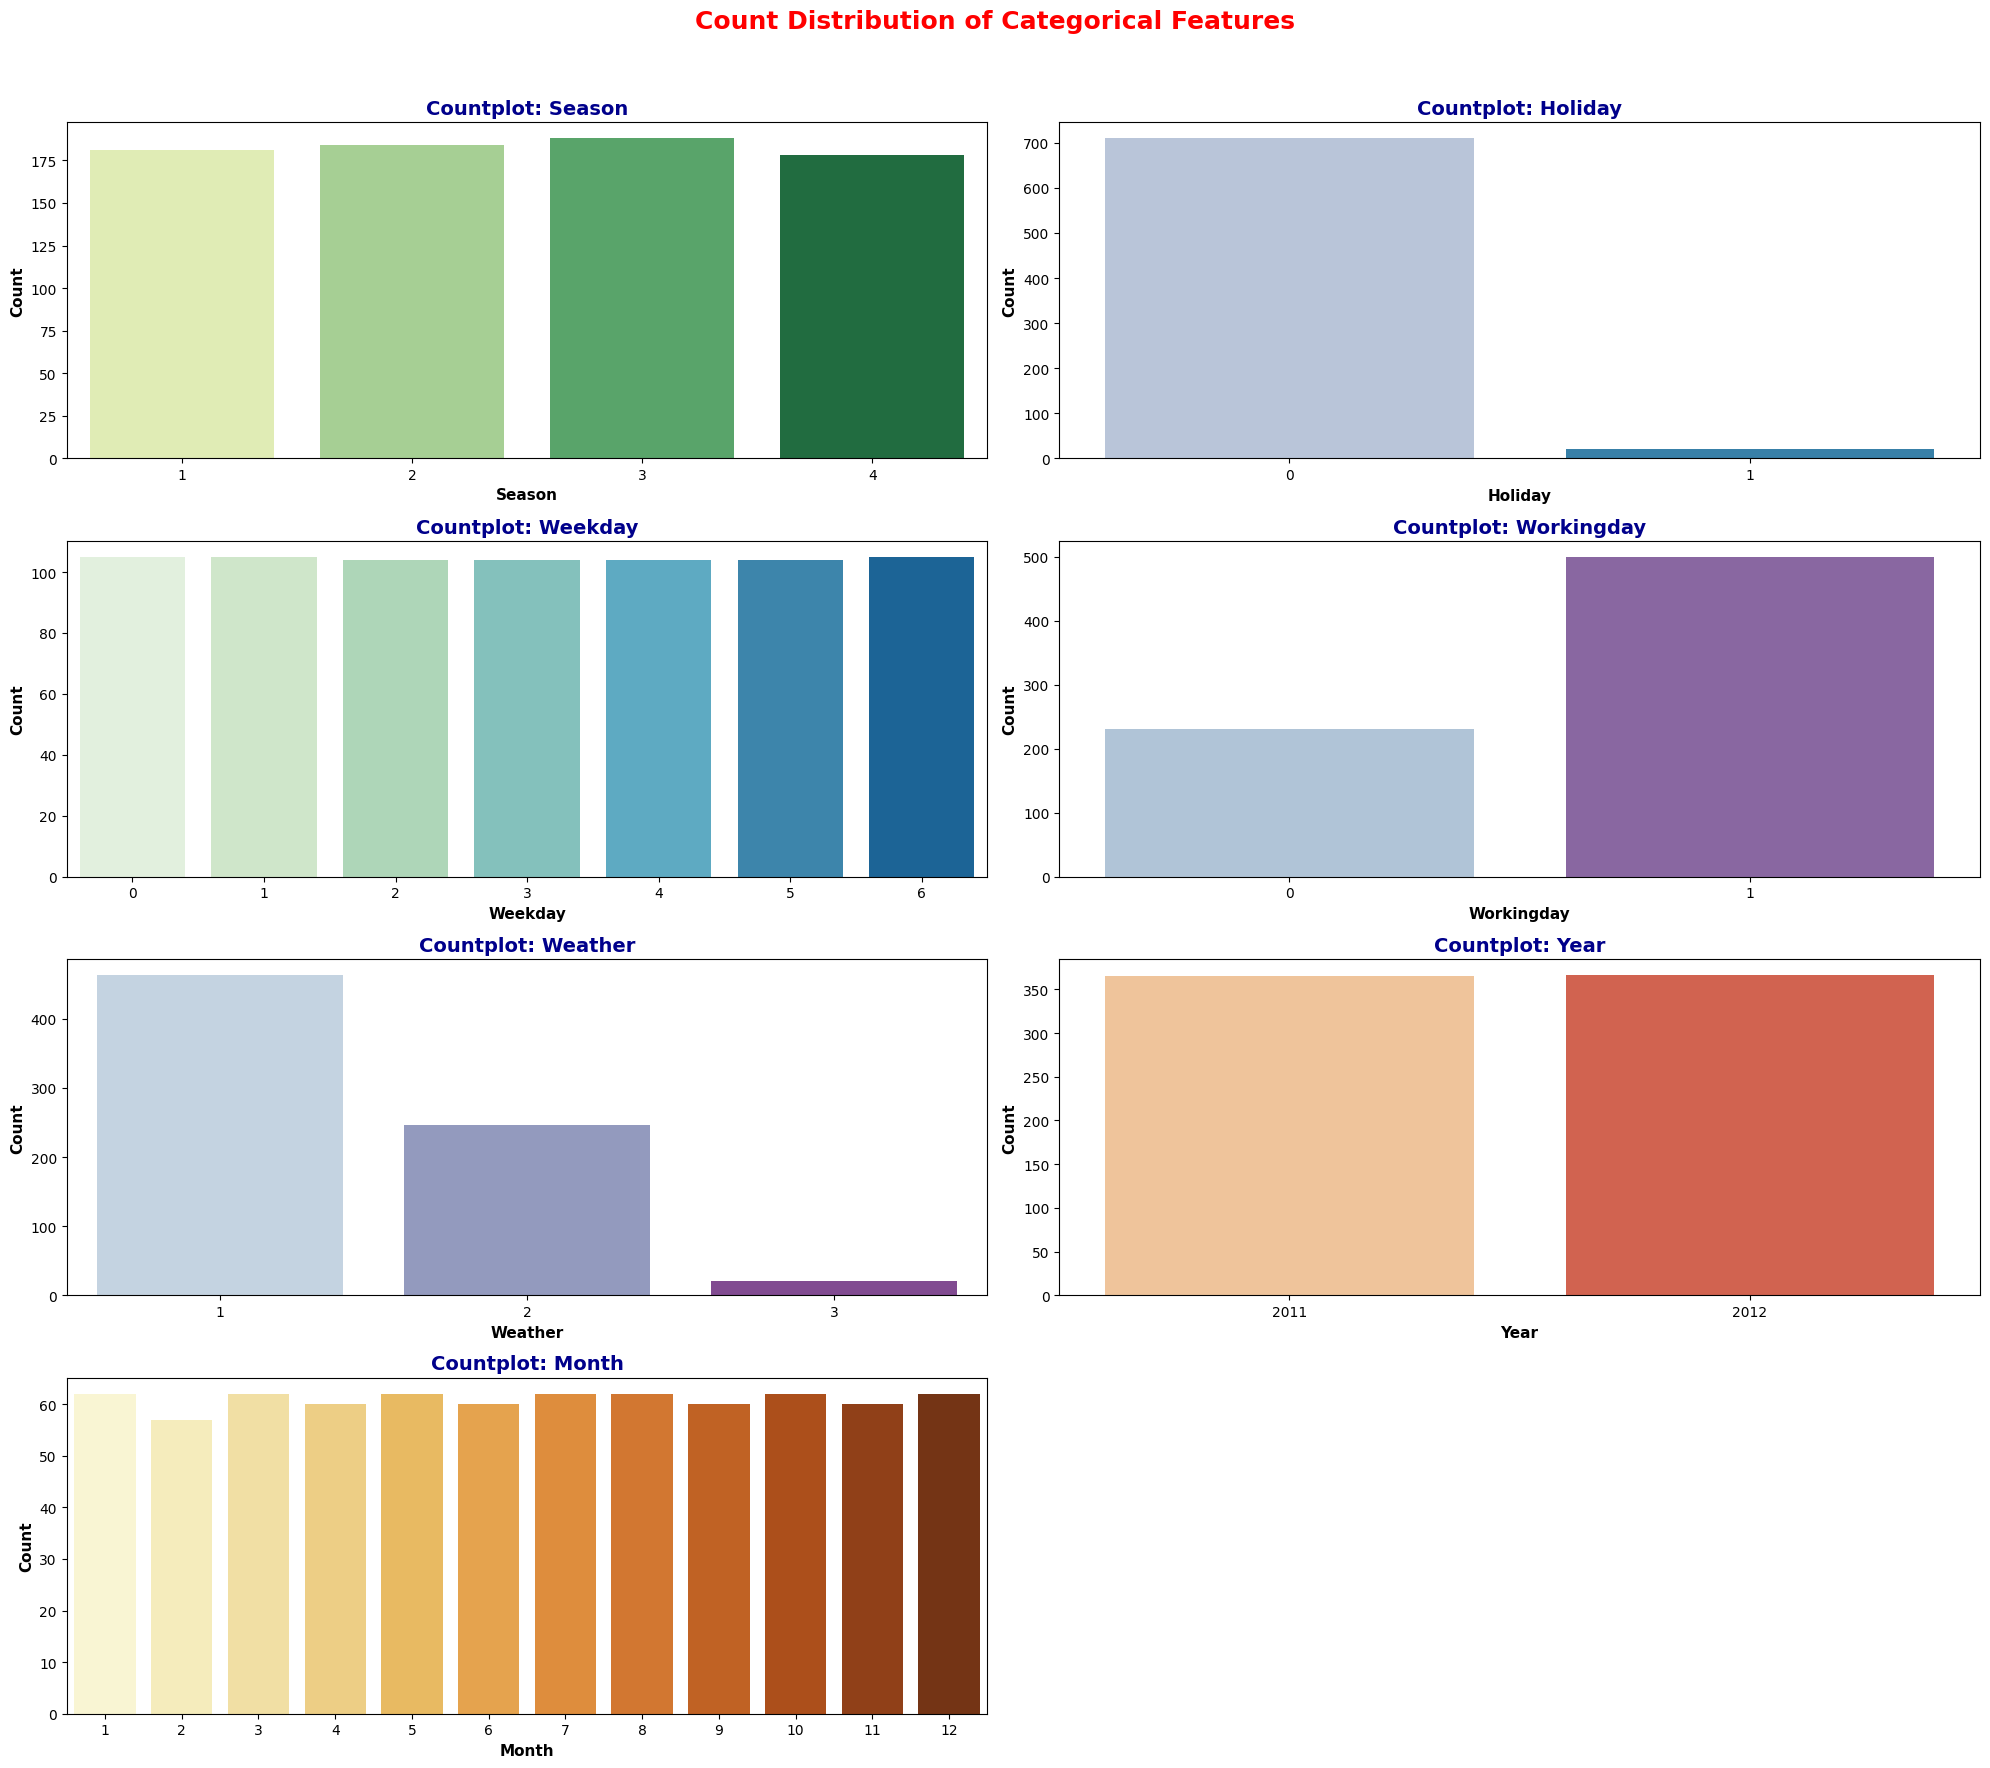

In [21]:
# Countplot of Categorical Features
features = ['season', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month']

# Color palettes for each subplot
color_palettes = ['YlGn', 'PuBu', 'GnBu', 'BuPu', 'BuPu', 'OrRd', 'YlOrBr']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (20, 18))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    sns.countplot(data = df, x = feature, ax = ax, palette = palette)
    ax.set_title(f'Countplot: {feature.replace("_", " ").title()}', fontsize = 14, fontweight = 'bold', color = 'darkblue')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize = 11, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 11, fontweight = 'bold')
    ax.tick_params(axis = 'x')

# Hide unused subplots if any
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Count Distribution of Categorical Features', fontsize = 18, fontweight = 'bold', color = 'red')
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

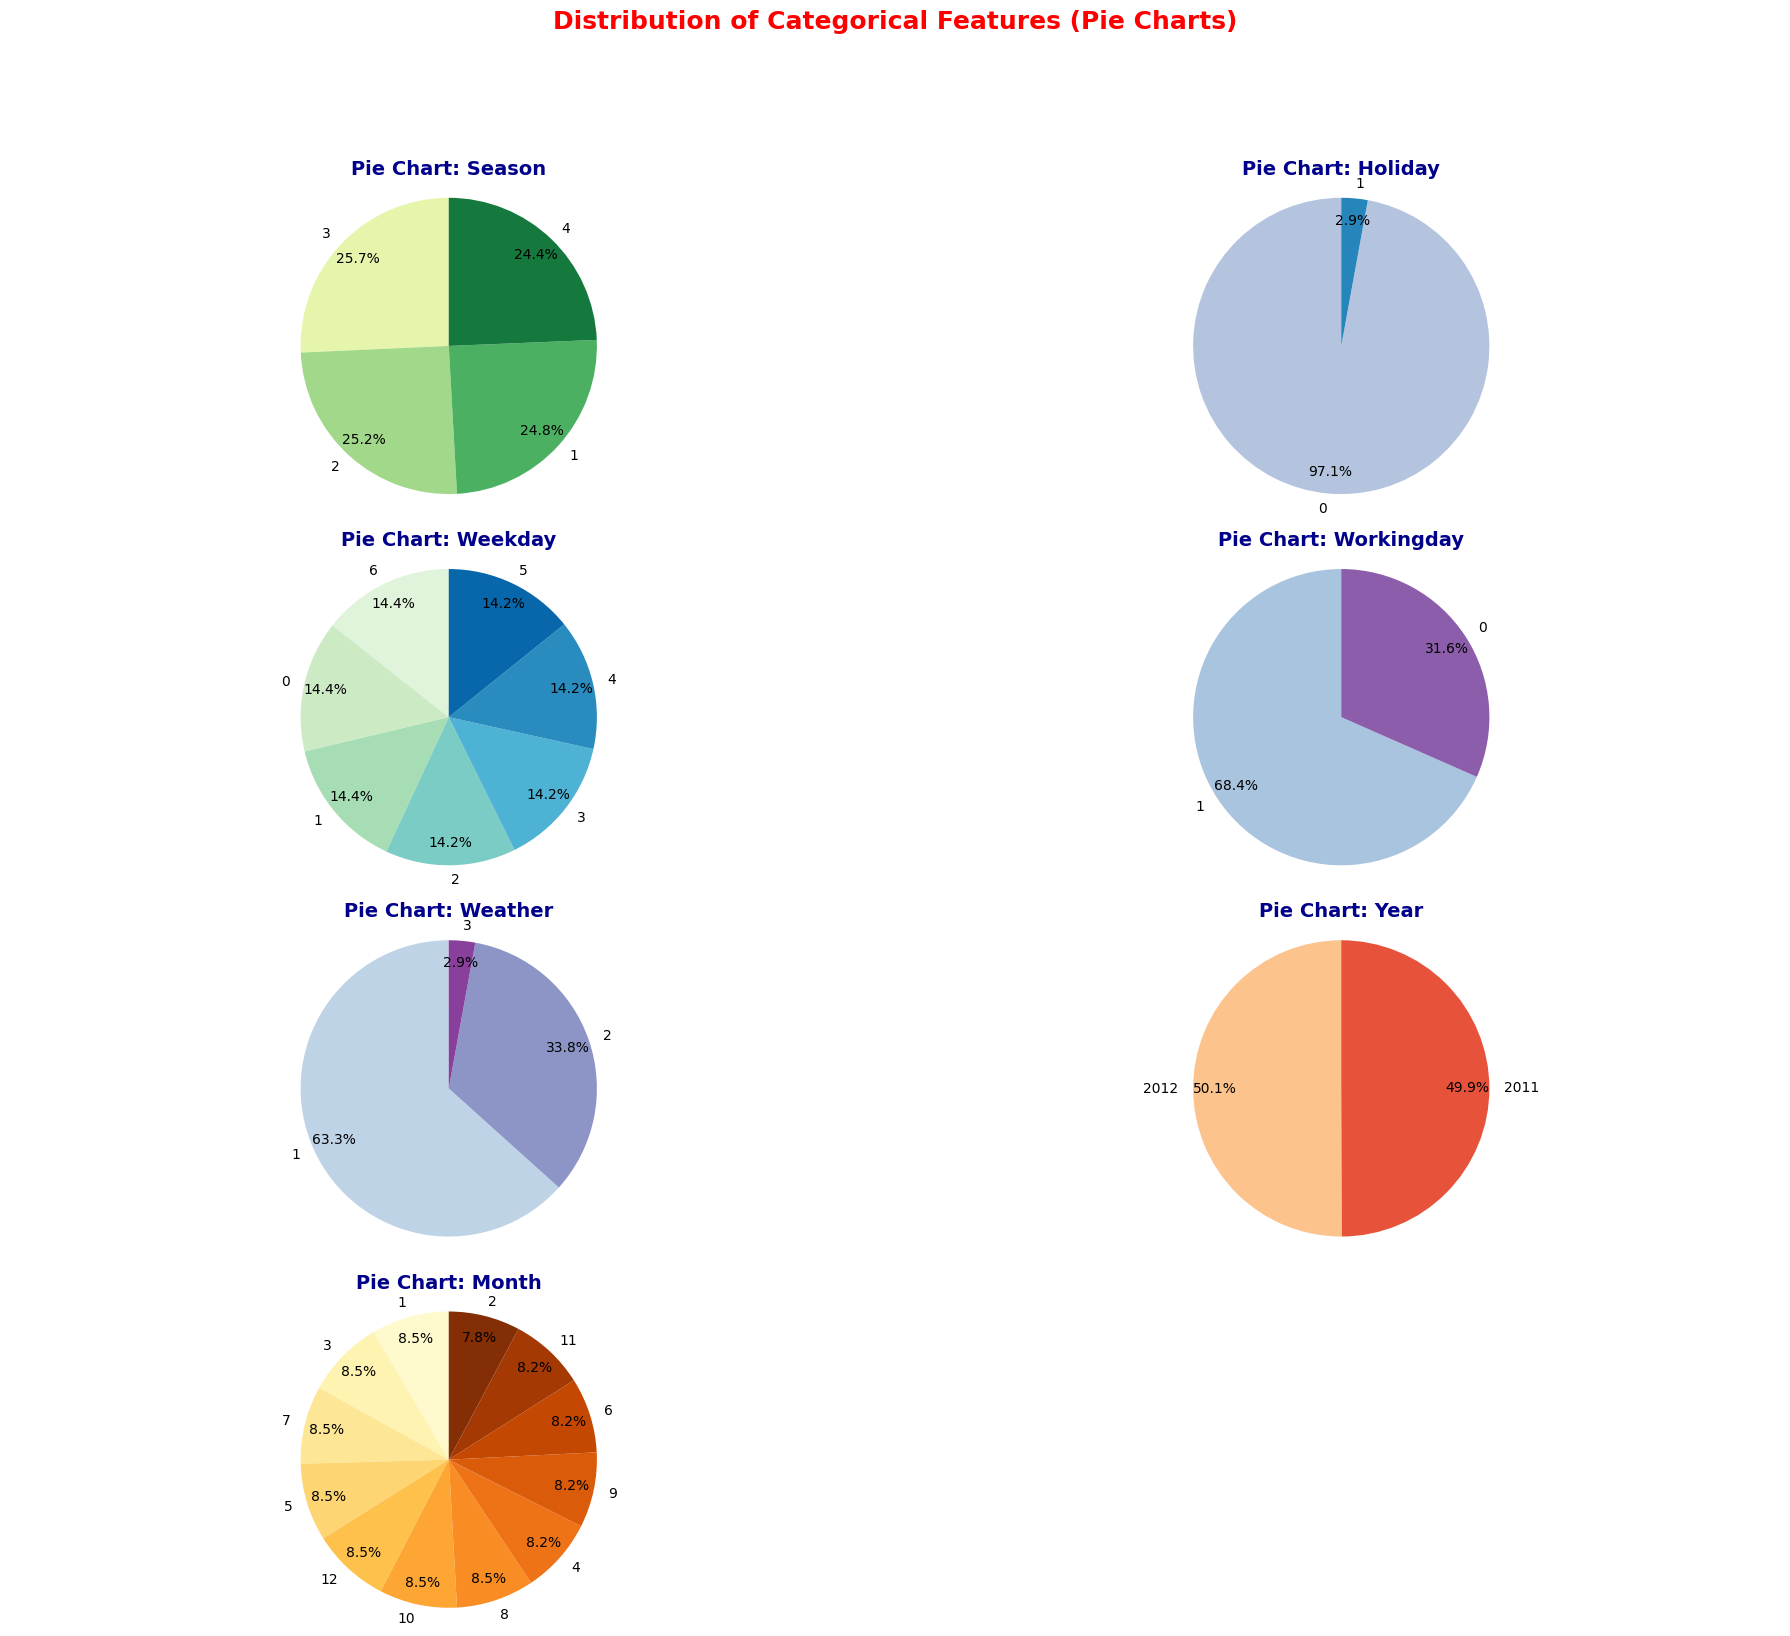

In [22]:
# Piechart of Categorical Features
features = ['season', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month']

# Color palettes for each subplot
color_palettes = ['YlGn', 'PuBu', 'GnBu', 'BuPu', 'BuPu', 'OrRd', 'YlOrBr']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (18, 16))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    # Get value counts and labels
    value_counts = df[feature].value_counts()
    labels = value_counts.index
    sizes = value_counts.values

    # Choose colors from palette
    colors = sns.color_palette(palette, n_colors = len(labels))

    # Pie chart
    ax.pie(sizes, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 90, textprops = {'fontsize': 10}, pctdistance = 0.85)

    # Equal aspect ratio ensures pie is circular
    ax.axis('equal')
    ax.set_title(f'Pie Chart: {feature.replace("_", " ").title()}',
                 fontsize = 14, fontweight = 'bold', color = 'darkblue')

# Hide any unused subplots (if fewer than 12 features)
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Categorical Features (Pie Charts)', fontsize = 18, fontweight = 'bold', color = 'red', y = 1.02)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

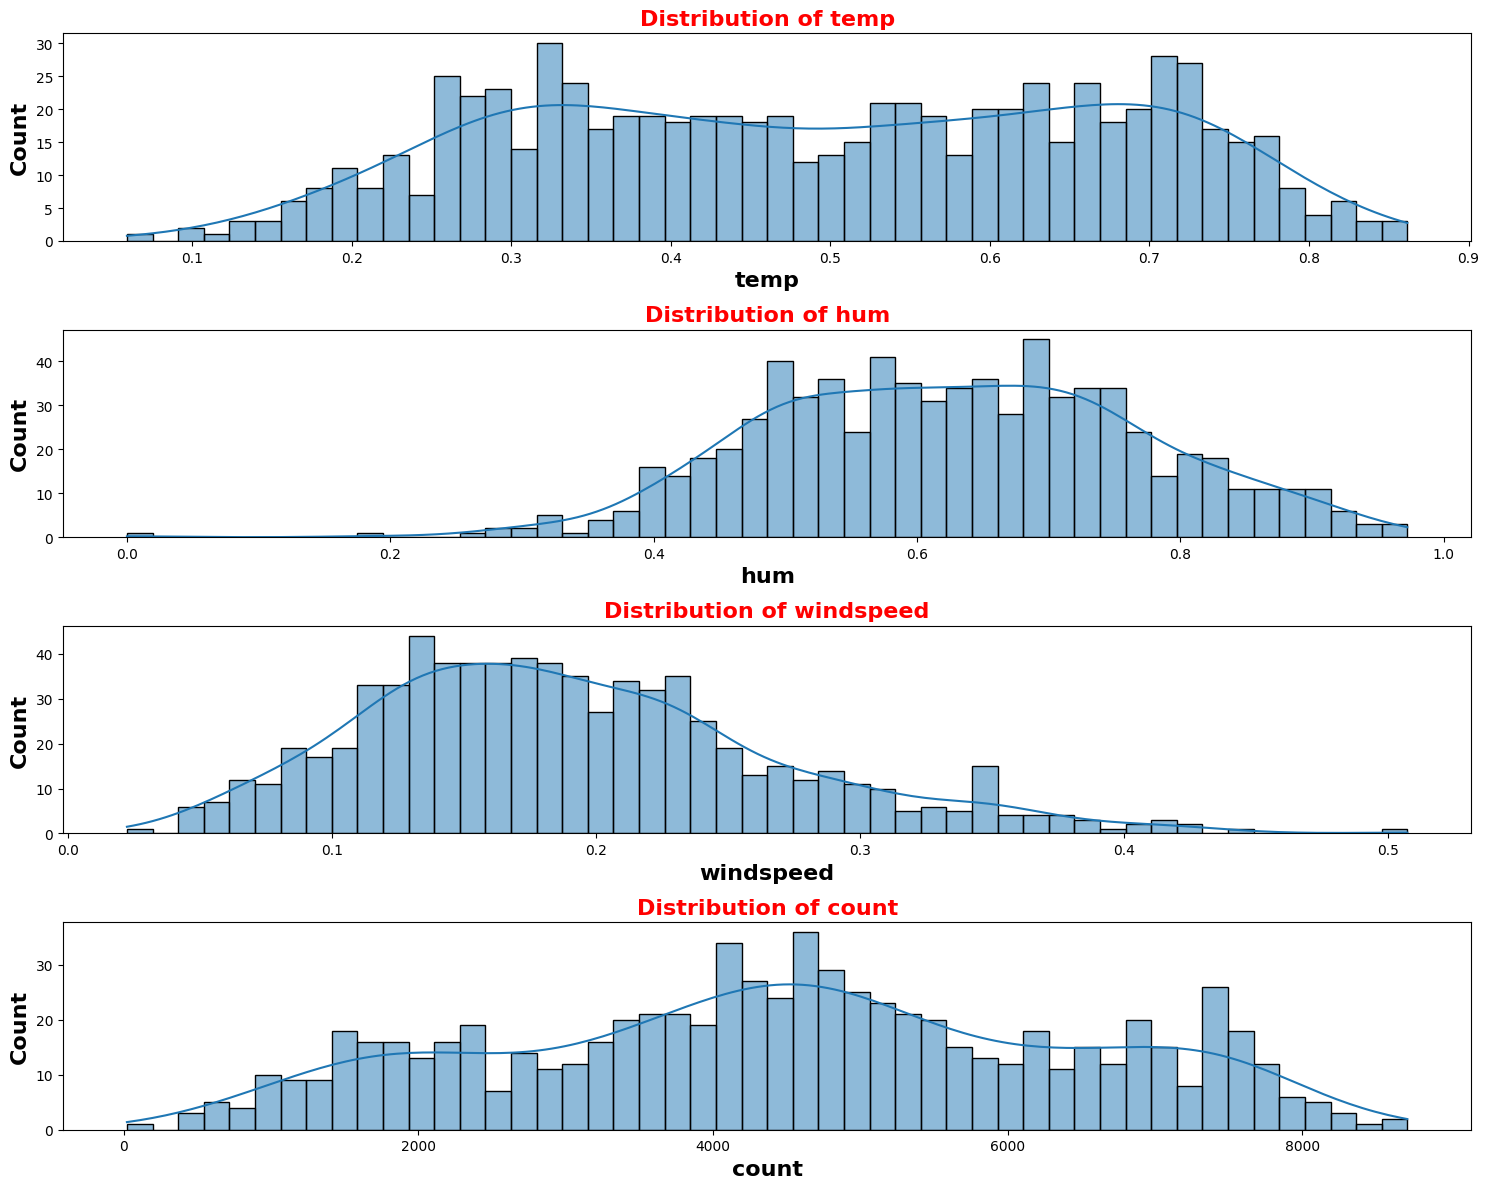

In [23]:
# Histplot for numerical features
features = ['temp', 'hum', 'windspeed', 'count']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 1, i)
    sns.histplot(data = df, x = col, kde = True, bins = 50)
    plt.title(f'Distribution of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

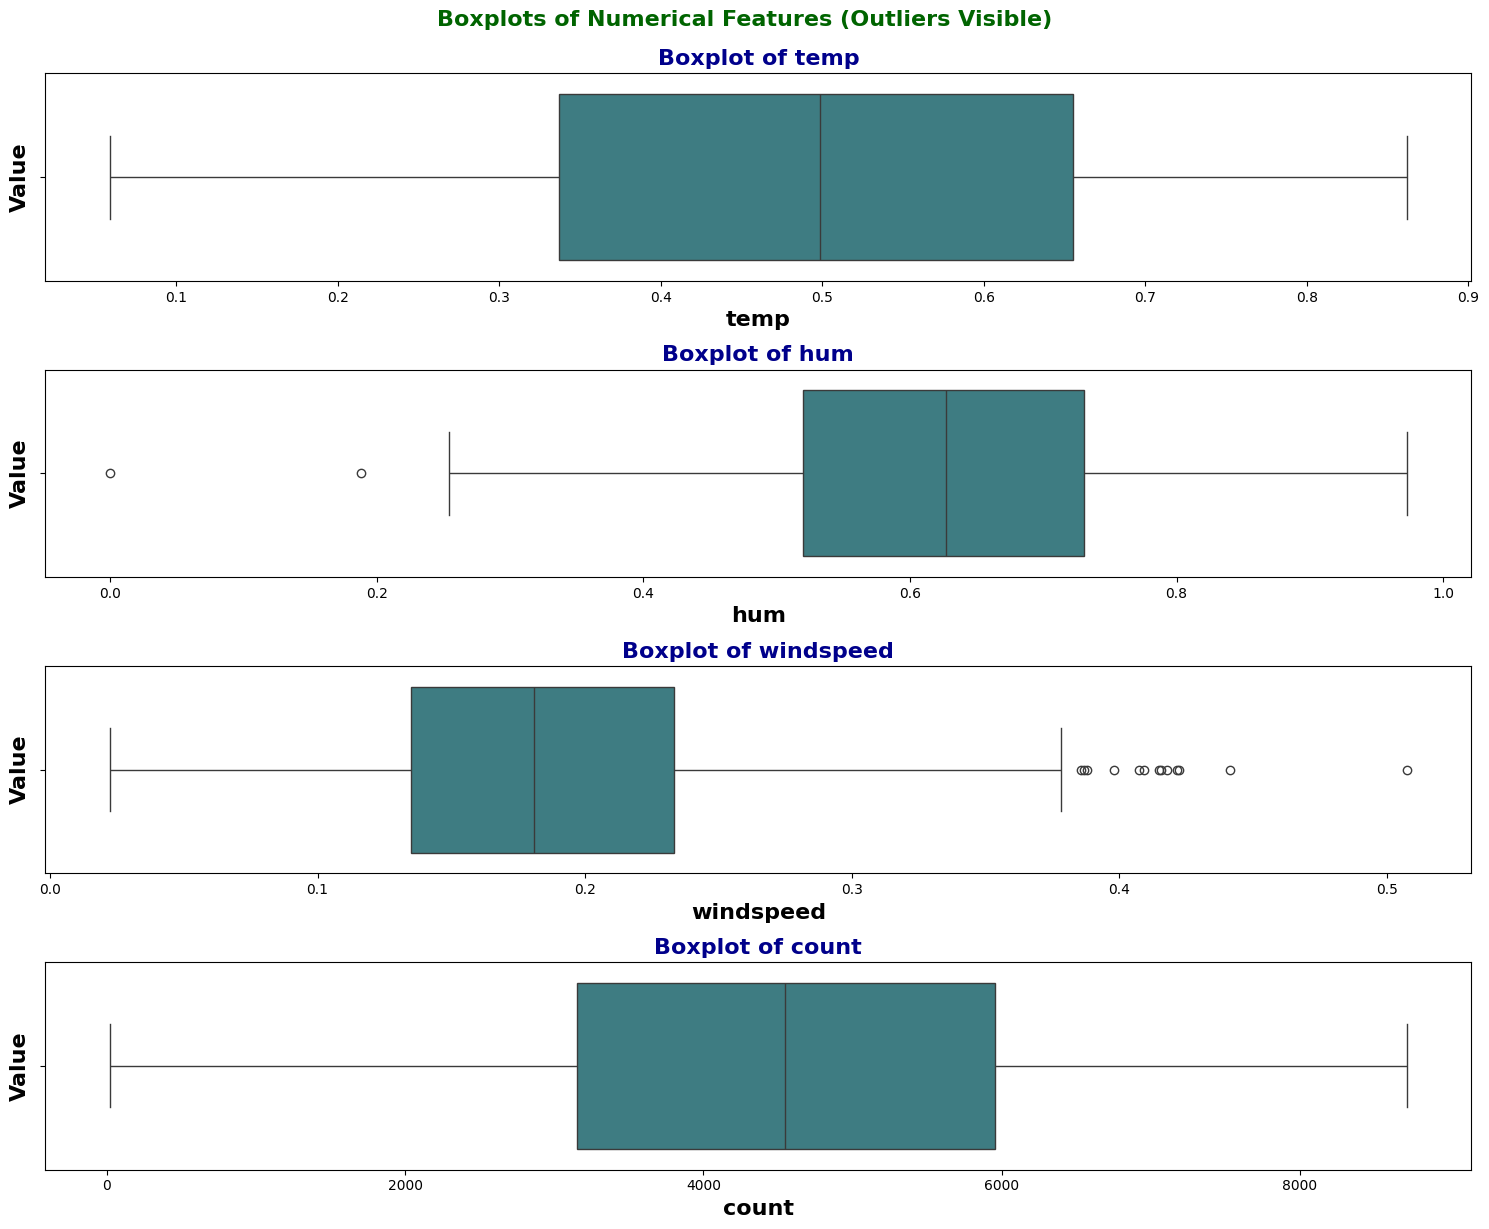

In [24]:
# Boxplot for numerical features
features = ['temp', 'hum', 'windspeed', 'count']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 1, i)
    sns.boxplot(data = df, x = col, orient = 'h', palette = 'crest')
    plt.title(f'Boxplot of {col}', fontsize = 16, fontweight = 'bold', color = 'darkblue')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Value', fontsize = 16, fontweight = 'bold')
    plt.xlabel(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

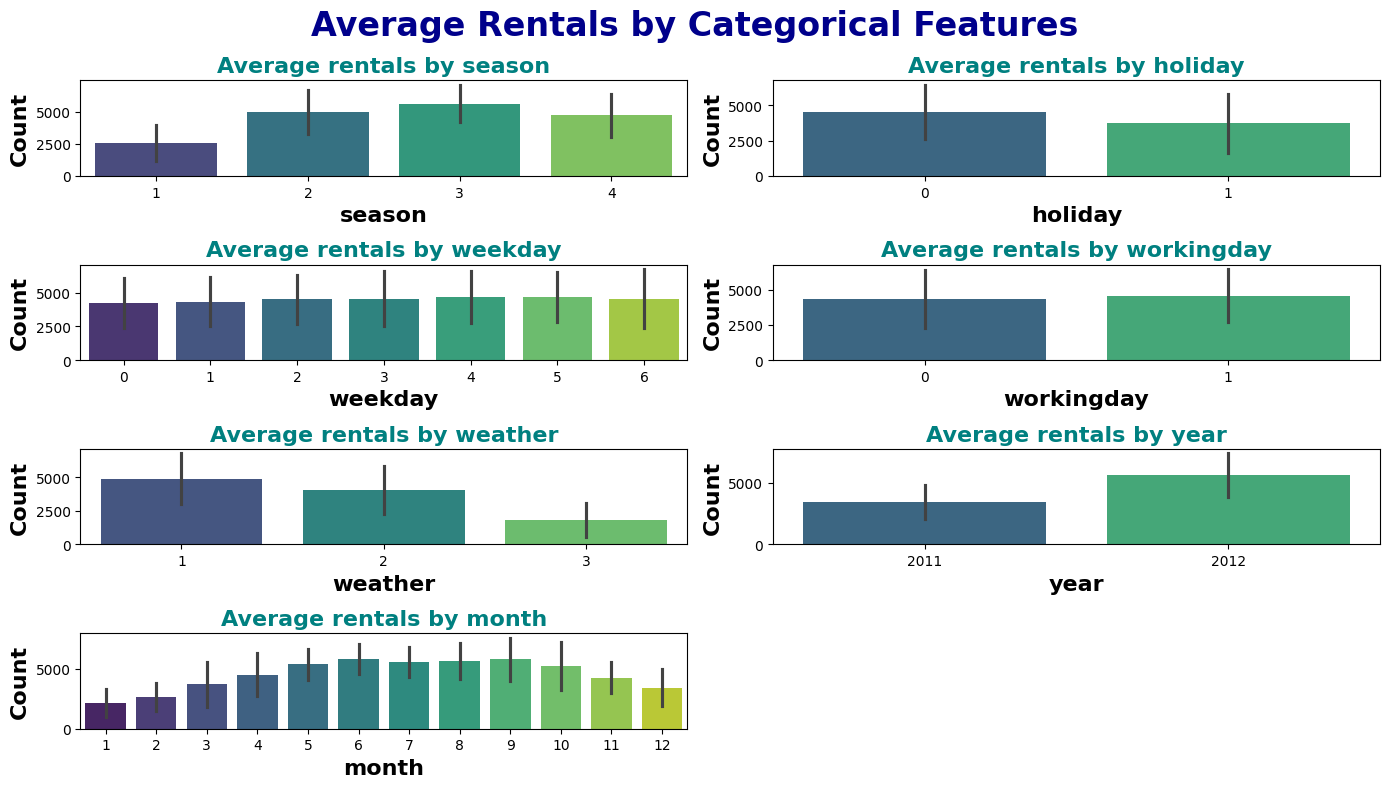

In [25]:
# Barplot (mean/median) + error bars – Categorical vs average count

plt.figure(figsize = (14, 8))
for i, col in enumerate(['season', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month'], 1):
    plt.subplot(4, 2, i)
    sns.barplot(x = col, y = 'count', data = df, estimator = 'mean', errorbar = 'sd', palette = 'viridis')
    plt.title(f'Average rentals by {col}', fontsize = 16, fontweight = 'bold', color = 'teal')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
    plt.suptitle('Average Rentals by Categorical Features', fontsize = 24, fontweight = 'bold', color = 'darkblue')
plt.tight_layout()
plt.show()

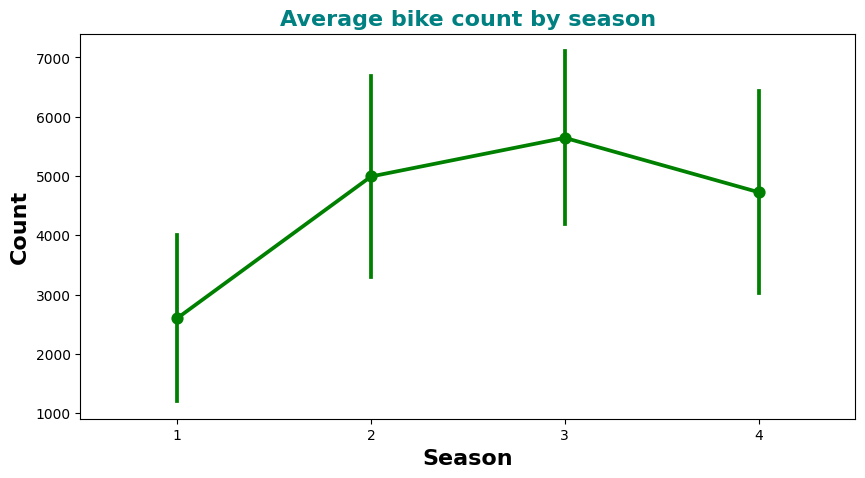

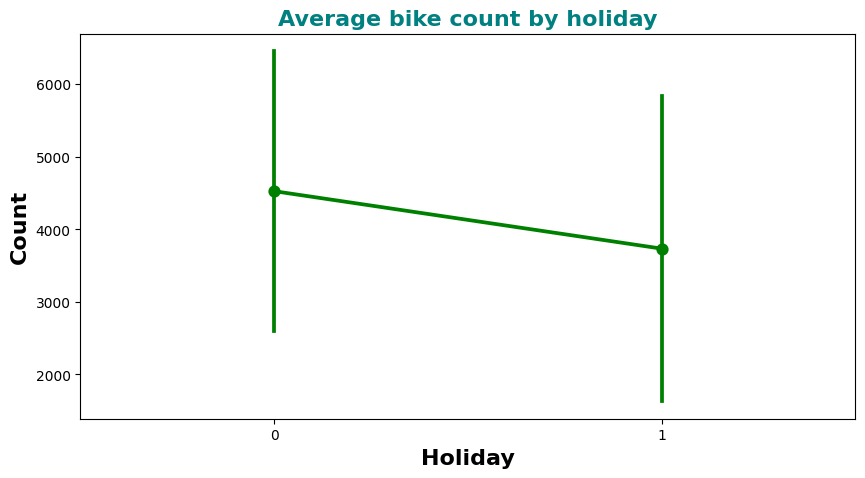

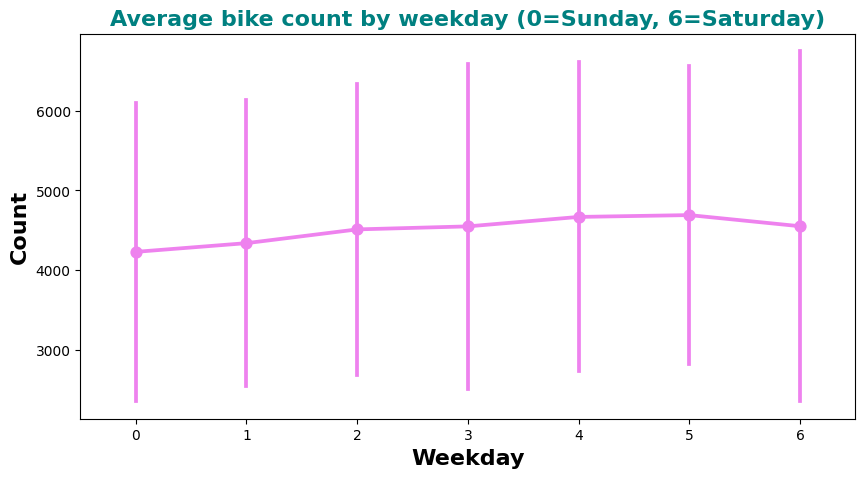

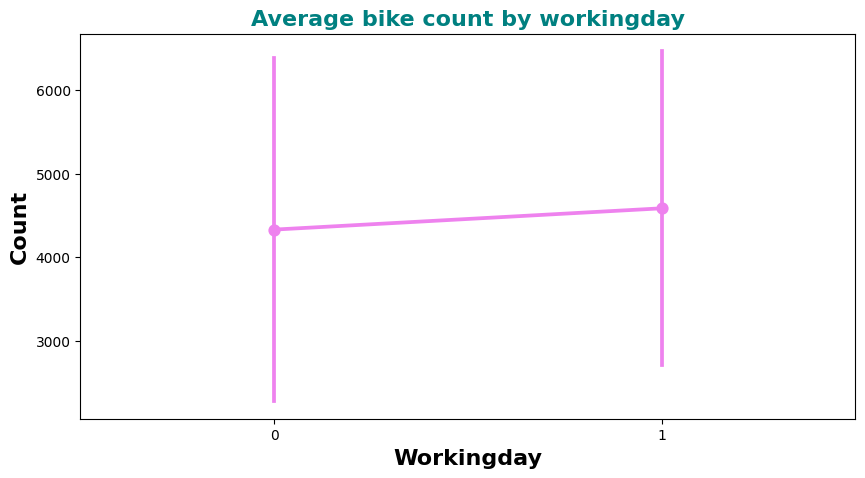

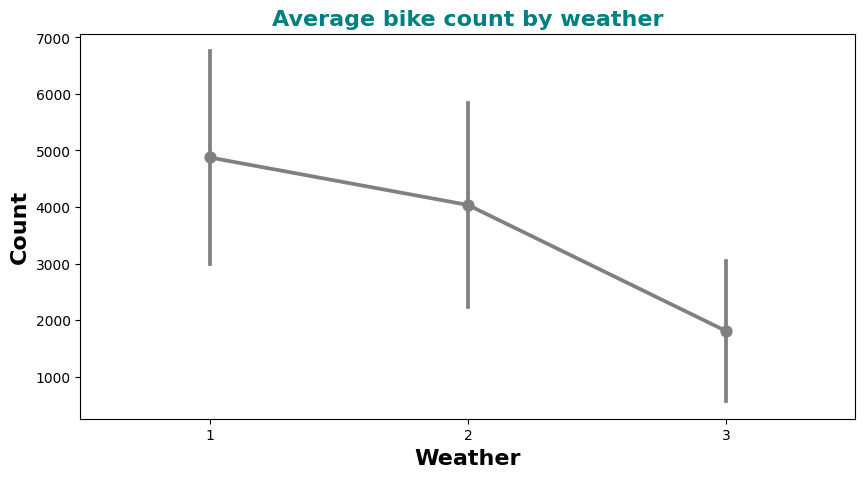

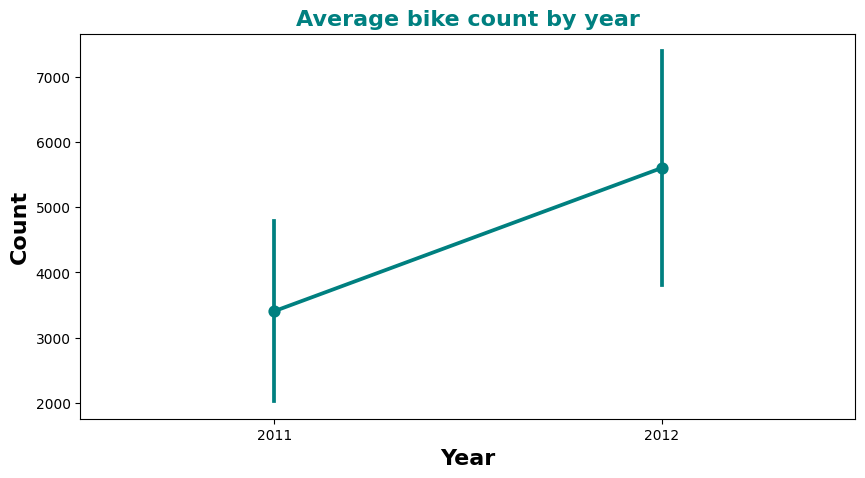

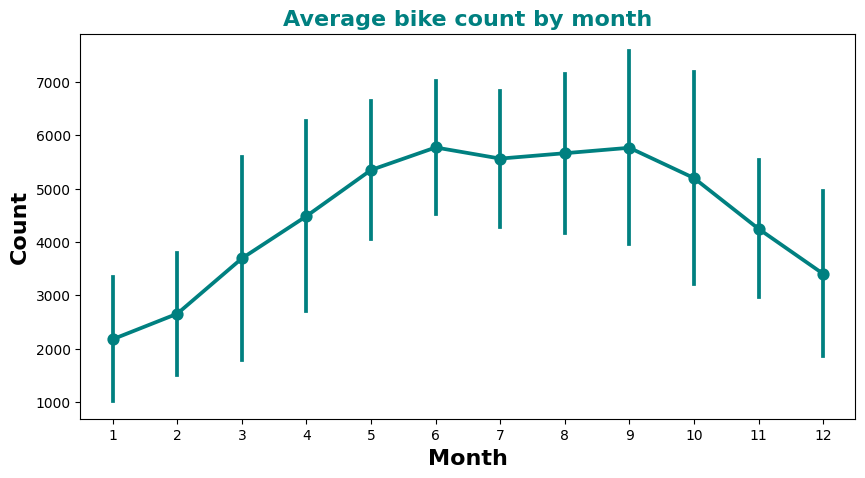

In [26]:
# Pointplot – Ordered categories vs count

# Season pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'season', y = 'count', data = df, errorbar = 'sd', color = 'green')
plt.title("Average bike count by season", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Holiday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'holiday', y = 'count', data = df, errorbar = 'sd', color = 'green')
plt.title("Average bike count by holiday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Holiday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Weekday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'weekday', y = 'count', data = df, errorbar = 'sd', color = 'violet')
plt.title("Average bike count by weekday (0=Sunday, 6=Saturday)", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Weekday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Workingday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'workingday', y = 'count', data = df, errorbar = 'sd', color = 'violet')
plt.title("Average bike count by workingday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Workingday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Weather pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'weather', y = 'count', data = df, errorbar = 'sd', color = 'grey')
plt.title("Average bike count by weather", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Weather", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Year trend
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'year', y = 'count', data = df, errorbar = 'sd', color = 'teal')
plt.title("Average bike count by year", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Year", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Month trend
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'month', y = 'count', data = df, errorbar = 'sd', color = 'teal')
plt.title("Average bike count by month", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Month", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

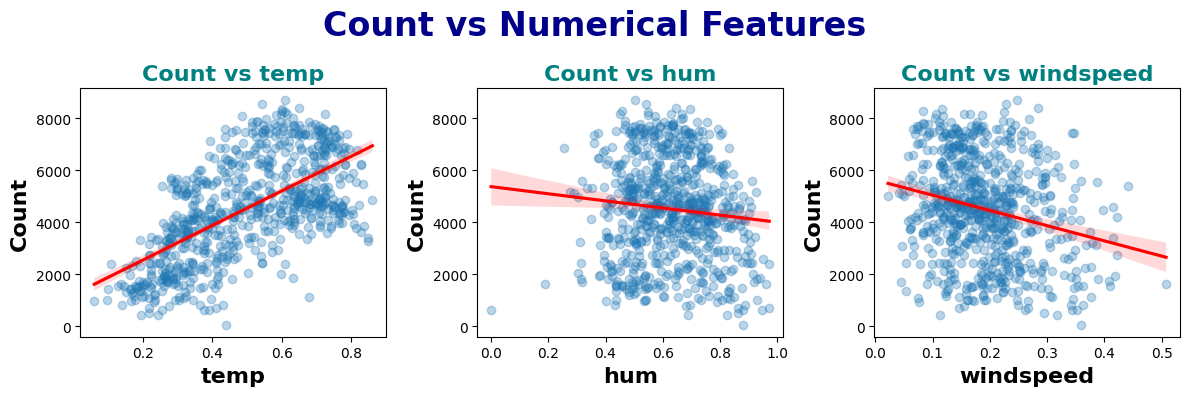

In [27]:
# Scatter + regression line – Numerical features vs countPython
num_features = ['temp', 'hum', 'windspeed']

plt.figure(figsize = (12, 4))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i+1)
    sns.regplot(x = col, y = 'count', data = df, scatter_kws = {'alpha':0.3}, line_kws = {'color':'red'})
    plt.title(f'Count vs {col}', fontsize = 16, fontweight = 'bold', color = 'teal')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.suptitle('Count vs Numerical Features', fontsize = 24, fontweight = 'bold', color = 'darkblue')
plt.tight_layout()
plt.show()

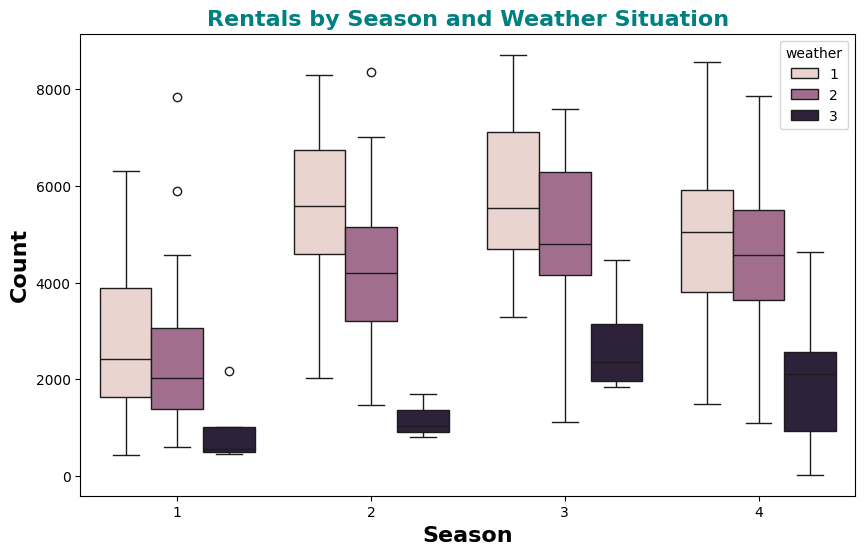

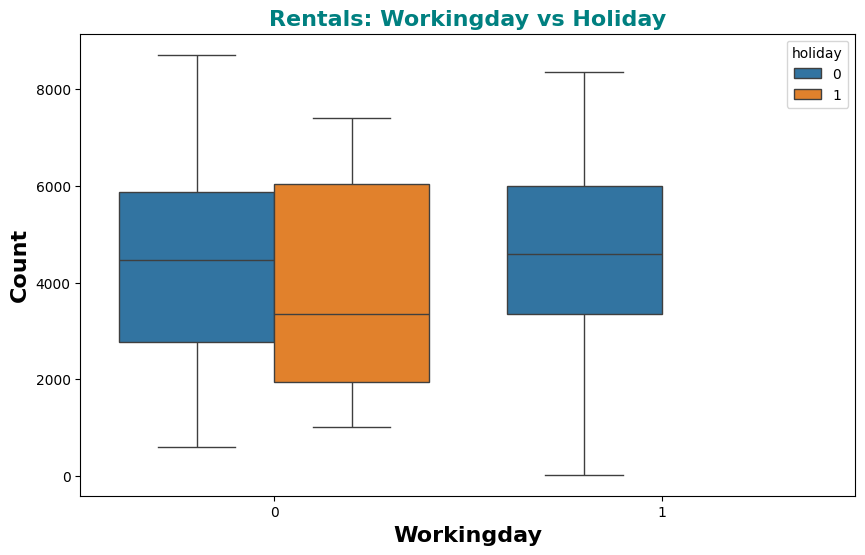

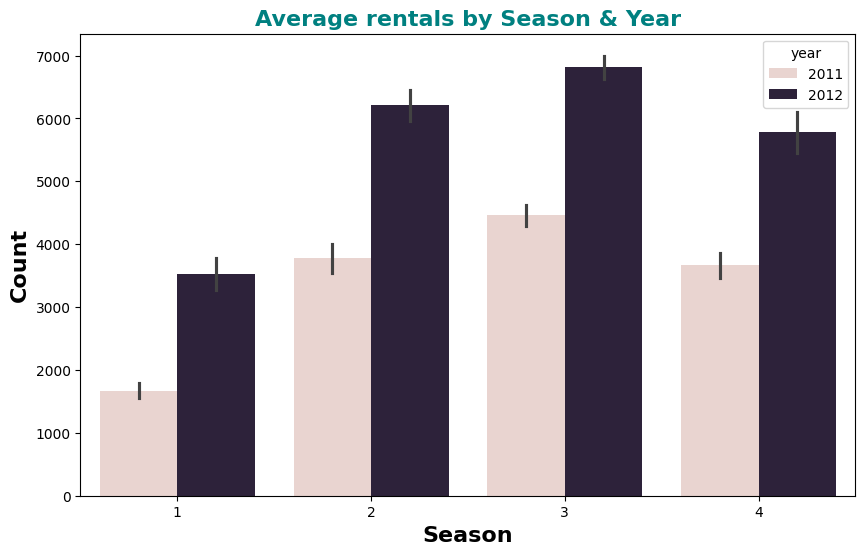

In [28]:
# Boxplot or barplot grouped by two variables
# Season × Weather
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'season', y = 'count', hue = 'weather', data = df)
plt.title("Rentals by Season and Weather Situation", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Workingday × Holiday
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'workingday', y = 'count', hue = 'holiday', data = df)
plt.title("Rentals: Workingday vs Holiday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Workingday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Season × Year
plt.figure(figsize = (10, 6))
sns.barplot(x = 'season', y = 'count', hue = 'year', data = df, estimator = 'mean')
plt.title("Average rentals by Season & Year", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

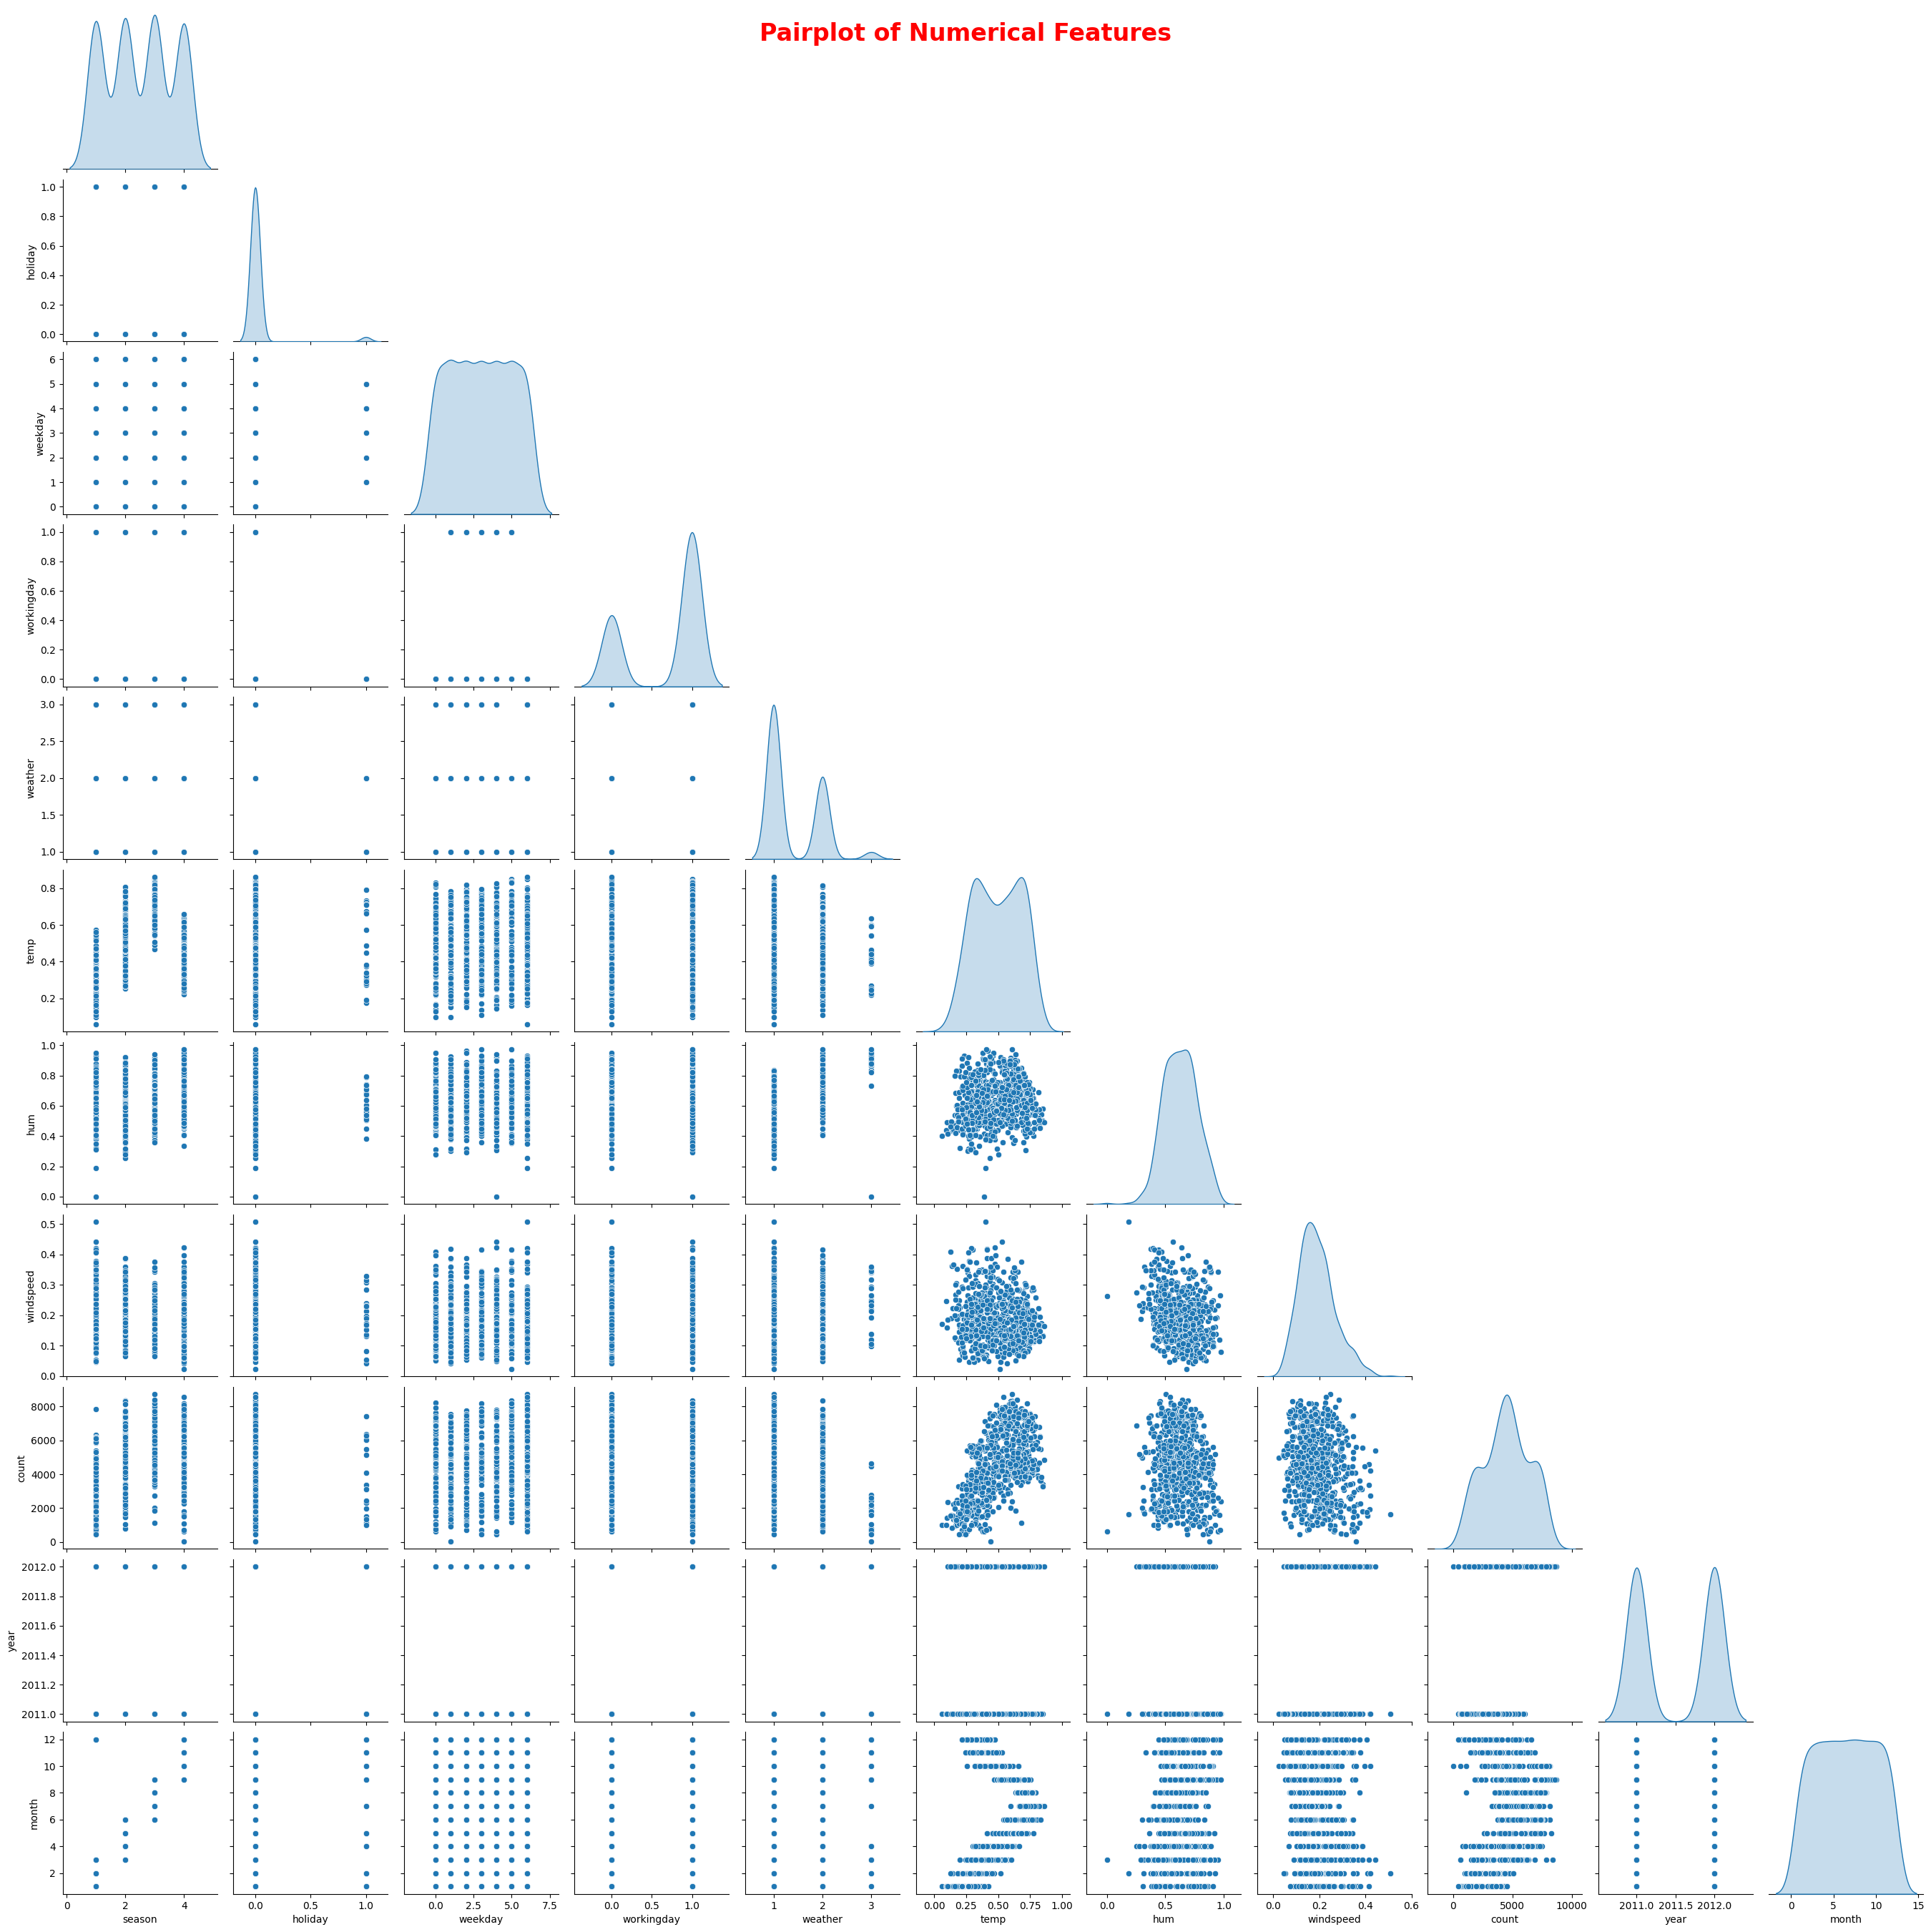

In [29]:
# Pairplot
sns.pairplot(df, diag_kind = 'kde', corner = True)
plt.suptitle('Pairplot of Numerical Features', fontsize = 24, fontweight = 'bold', color = 'red')
plt.show()

# **Linear Regression Model**

## **A: Import the required libraries**

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# **B: Load & prepare data**

In [31]:
X = df.drop('count', axis = 1)
y = df['count']

# Apply log transformation before modeling. Handles right-skew + reduces impact of high outliers
y = np.log1p(y)

# **C: Train Validation Test Split**

# **60% train, 20% validation, 20% test**

In [32]:
# Train Validation Test Split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state = 42)

print(f"Original size: {len(X):4d} rows")
print(f"Train size: {len(X_train):4d} rows")
print(f"Validation size: {len(X_val):4d} rows")
print(f"Test size: {len(X_test):4d} rows")


Original size:  731 rows
Train size:  438 rows
Validation size:  146 rows
Test size:  147 rows


# **D: Missing values and Outliers Treatment**

The boxplots of numerical features (`temp`, `hum`, `windspeed`, `count`) show a few potential outliers, particularly:
- A small number of very low values in `hum`
- Several high values in `windspeed`
- Multiple high outliers in the target variable `count` (likely legitimate peak demand days).

Given the small dataset size (only 730 observations), removing or heavily modifying outliers risks losing valuable information, especially since extreme values in bike rentals often correspond to real-world events (e.g., exceptionally good weather, holidays, or special days).

Linear regression (especially with Ridge regularization) is reasonably robust to moderate outliers, and log-transforming the target variable further reduces their influence.

Therefore, **no rows will be removed**, and no aggressive clipping will be applied at this stage. Instead:
- We will apply **log transformation** to the target (`count`) to handle right-skewness and reduce outlier impact.
- Regularization (Ridge) will help stabilize the model.

The dataset is clean with **no missing values**.

Below is the code used to quantify the number of outliers using the IQR method (with 1.5× and 3× IQR thresholds for reference).

In [33]:
def count_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), outliers.index.tolist()

# Features to check
num_cols = ['temp', 'hum', 'windspeed', 'count']

print("Outlier counts using IQR method:\n")
for col in num_cols:
    count_1_5, idx_1_5 = count_outliers_iqr(df[col], multiplier=1.5)
    count_3_0, idx_3_0 = count_outliers_iqr(df[col], multiplier=3.0)

    print(f"{col}:")
    print(f"  • {count_1_5} outliers at 1.5 × IQR ({count_1_5 / len(df):.1%} of data)")
    print(f"  • {count_3_0} outliers at 3.0 × IQR  ({count_3_0 / len(df):.1%} of data)")
    print()

Outlier counts using IQR method:

temp:
  • 0 outliers at 1.5 × IQR (0.0% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)

hum:
  • 2 outliers at 1.5 × IQR (0.3% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)

windspeed:
  • 13 outliers at 1.5 × IQR (1.8% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)

count:
  • 0 outliers at 1.5 × IQR (0.0% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)



# **E: Encoding and Scaling**

In [34]:
# Encoding

onehot_cols = ['season', 'month', 'weekday', 'weather']
encoder = OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore')

# Fit ONLY on train
encoder.fit(X_train[onehot_cols])

# Transform all sets
X_train_onehot = encoder.transform(X_train[onehot_cols])
X_val_onehot = encoder.transform(X_val[onehot_cols])
X_test_onehot = encoder.transform(X_test[onehot_cols])

X_train_onehot = pd.DataFrame(X_train_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_train.index)
X_val_onehot = pd.DataFrame(X_val_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_val.index)
X_test_onehot = pd.DataFrame(X_test_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_test.index)

In [35]:
# Scaling

scale_cols  = ['temp', 'hum', 'windspeed']
scaler = StandardScaler()

# Fit ONLY on train
scaler.fit(X_train[scale_cols])

# Transform all sets
X_train_scaled = pd.DataFrame(scaler.transform(X_train[scale_cols]), index = X_train.index, columns = scale_cols)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val[scale_cols]), index = X_val.index, columns = scale_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test[scale_cols]), index = X_test.index, columns = scale_cols)

In [36]:
binary_cols = ['holiday', 'workingday', 'year']

X_train_final = pd.concat([X_train_onehot, X_train_scaled, X_train[binary_cols]], axis = 1)
X_val_final = pd.concat([X_val_onehot, X_val_scaled, X_val[binary_cols]], axis = 1)
X_test_final = pd.concat([X_test_onehot, X_test_scaled, X_test[binary_cols]], axis = 1)

# **F: Multiple Linear Regression Models**

1. Baseline: Multiple Linear Regression (OLS)
2. Ridge (L2 Regularization)
3. Lasso (L1 Regularization)
4. ElasticNet (L1 + L2 Mix)

# **1. Baseline: Multiple Linear Regression (OLS)**

In [37]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train_final)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary(),"\n")

# Predict & evaluate on train set and validation set
X_train_sm = sm.add_constant(X_train_final, has_constant = 'add')
y_train_pred = ols_model.predict(X_train_sm)
X_val_sm = sm.add_constant(X_val_final, has_constant = 'add')
y_val_pred = ols_model.predict(X_val_sm)

# Training set Evaluation
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_score_train = r2_score(y_train, y_train_pred)

print(f"MAE of Baseline Model: {mae_train:,.2f}")
print(f"MSE of Baseline Model: {mse_train:,.2f}")
print(f"RMSE of Baseline Model: {rmse_train:,.2f}")
print(f"R² of Baseline Model: {r2_score_train:.4f}")

# Validation set Evaluation
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_score_val = r2_score(y_val, y_val_pred)

print(f"MAE of Baseline Model: {mae_val:,.2f}")
print(f"MSE of Baseline Model: {mse_val:,.2f}")
print(f"RMSE of Baseline Model: {rmse_val:,.2f}")
print(f"R² of Baseline Model: {r2_score_val:.4f}")

# Show key stats from statsmodels summary
print("\nBaseline Linear Regression OLS Model Summary Highlights:")
print(f"Overall R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic p-value: {ols_model.f_pvalue:.6f}")
print(f"Number of observations: {ols_model.nobs}")

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     71.61
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          4.00e-137
Time:                        04:57:07   Log-Likelihood:                 10.358
No. Observations:                 438   AIC:                             35.28
Df Residuals:                     410   BIC:                             149.6
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -937.0004     48.811    -19.196      0.0

# **2. Ridge (L2 Regularization)**

In [38]:
# Define alpha range
alphas = np.logspace(-4,3,100)

# 5-fold CV and ridgecv.fit()
ridge_cv = RidgeCV(alphas = alphas, cv = 5, scoring = 'neg_root_mean_squared_error')
ridge_cv.fit(X_train_final, y_train)

print(f"Best alpha for RidgeCV: {ridge_cv.alpha_:.6f}")
print(f"Best score for RidgeCV: {-ridge_cv.best_score_:.6f}")

# Predictions
y_train_pred_ridge = ridge_cv.predict(X_train_final)
y_val_pred_ridge = ridge_cv.predict(X_val_final)

# Training set Evaluation
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)
r2_score_train_ridge = r2_score(y_train, y_train_pred_ridge)

print(f"MAE of Ridge Model: {mae_train_ridge:,.2f}")
print(f"MSE of Ridge Model: {mse_train_ridge:,.2f}")
print(f"RMSE of Ridge Model: {rmse_train_ridge:,.2f}")
print(f"R² of Ridge Model: {r2_score_train_ridge:.4f}")

# Validation set Evaluation
mae_val_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
mse_val_ridge = mean_squared_error(y_val, y_val_pred_ridge)
rmse_val_ridge = np.sqrt(mse_val_ridge)
r2_score_val_ridge = r2_score(y_val, y_val_pred_ridge)

print(f"MAE of Ridge Model: {mae_val_ridge:,.2f}")
print(f"MSE of Ridge Model: {mse_val_ridge:,.2f}")
print(f"RMSE of Ridge Model: {rmse_val_ridge:,.2f}")
print(f"R² of Ridge Model: {r2_score_val_ridge:.4f}")

Best alpha for RidgeCV: 0.403702
Best score for RidgeCV: 0.258104
MAE of Ridge Model: 0.17
MSE of Ridge Model: 0.06
RMSE of Ridge Model: 0.24
R² of Ridge Model: 0.8245
MAE of Ridge Model: 0.17
MSE of Ridge Model: 0.05
RMSE of Ridge Model: 0.23
R² of Ridge Model: 0.7938


# **3. Lasso (L1 Regularization)**

In [39]:
# Define alpha range
alphas = np.logspace(-4,3,100)

# 5-fold CV and lassocv.fit()
lasso_cv = LassoCV(alphas = alphas, cv = 5, max_iter = 5000, random_state = 42)
lasso_cv.fit(X_train_final, y_train)

print(f"Best alpha for LassoCV: {lasso_cv.alpha_:.6f}")

# Predictions
y_train_pred_lasso = lasso_cv.predict(X_train_final)
y_val_pred_lasso = lasso_cv.predict(X_val_final)

# Training set Evaluation
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mse_train_lasso)
r2_score_train_lasso = r2_score(y_train, y_train_pred_lasso)

print(f"MAE of Lasso Model: {mae_train_lasso:,.2f}")
print(f"MSE of Lasso Model: {mse_train_lasso:,.2f}")
print(f"RMSE of Lasso Model: {rmse_train_lasso:,.2f}")
print(f"R² of Lasso Model: {r2_score_train_lasso:.4f}")

# Validation set Evaluation
mae_val_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
mse_val_lasso = mean_squared_error(y_val, y_val_pred_lasso)
rmse_val_lasso = np.sqrt(mse_val_lasso)
r2_score_val_lasso = r2_score(y_val, y_val_pred_lasso)

print(f"MAE of Lasso Model: {mae_val_lasso:,.2f}")
print(f"MSE of Lasso Model: {mse_val_lasso:,.2f}")
print(f"RMSE of Lasso Model: {rmse_val_lasso:,.2f}")
print(f"R² of Lasso Model: {r2_score_val_lasso:.4f}")

Best alpha for LassoCV: 0.000705
MAE of Lasso Model: 0.17
MSE of Lasso Model: 0.06
RMSE of Lasso Model: 0.24
R² of Lasso Model: 0.8231
MAE of Lasso Model: 0.17
MSE of Lasso Model: 0.05
RMSE of Lasso Model: 0.23
R² of Lasso Model: 0.7977


# **4. ElasticNet (L1 + L2 Mix)**

In [40]:
# Define alpha range
alphas = np.logspace(-4,3,100)

# 5-fold CV and elasticnetcv.fit()
elnet_cv = ElasticNetCV(alphas = alphas, cv = 5, max_iter = 5000, random_state = 42, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0])
elnet_cv.fit(X_train_final, y_train)

print(f"Best alpha for ElasticNetCV: {elnet_cv.alpha_:.6f}")
print(f"Best l1_ratio: {elnet_cv.l1_ratio_:.3f}")

# Predictions
y_train_pred_elnet = elnet_cv.predict(X_train_final)
y_val_pred_elnet = elnet_cv.predict(X_val_final)

# Training set Evaluation
mae_train_elnet = mean_absolute_error(y_train, y_train_pred_elnet)
mse_train_elnet = mean_squared_error(y_train, y_train_pred_elnet)
rmse_train_elnet = np.sqrt(mse_train_elnet)
r2_score_train_elnet = r2_score(y_train, y_train_pred_elnet)

print(f"MAE of ElasticNet Model: {mae_train_elnet:,.2f}")
print(f"MSE of ElasticNet Model: {mse_train_elnet:,.2f}")
print(f"RMSE of ElasticNet Model: {rmse_train_elnet:,.2f}")
print(f"R² of ElasticNet Model: {r2_score_train_elnet:.4f}")

# Validation set Evaluation
mae_val_elnet = mean_absolute_error(y_val, y_val_pred_elnet)
mse_val_elnet = mean_squared_error(y_val, y_val_pred_elnet)
rmse_val_elnet = np.sqrt(mse_val_elnet)
r2_score_val_elnet = r2_score(y_val, y_val_pred_elnet)

print(f"MAE of ElasticNet Model: {mae_val_elnet:,.2f}")
print(f"MSE of ElasticNet Model: {mse_val_elnet:,.2f}")
print(f"RMSE of ElasticNet Model: {rmse_val_elnet:,.2f}")
print(f"R² of ElasticNet Model: {r2_score_val_elnet:.4f}")

Best alpha for ElasticNetCV: 0.000705
Best l1_ratio: 1.000
MAE of ElasticNet Model: 0.17
MSE of ElasticNet Model: 0.06
RMSE of ElasticNet Model: 0.24
R² of ElasticNet Model: 0.8231
MAE of ElasticNet Model: 0.17
MSE of ElasticNet Model: 0.05
RMSE of ElasticNet Model: 0.23
R² of ElasticNet Model: 0.7977


In [41]:
# Residual Diagnostics. Residuals = actual - predicted
res_ridge = y_val - y_val_pred_ridge
res_lasso = y_val - y_val_pred_lasso
res_elnet  = y_val - y_val_pred_elnet

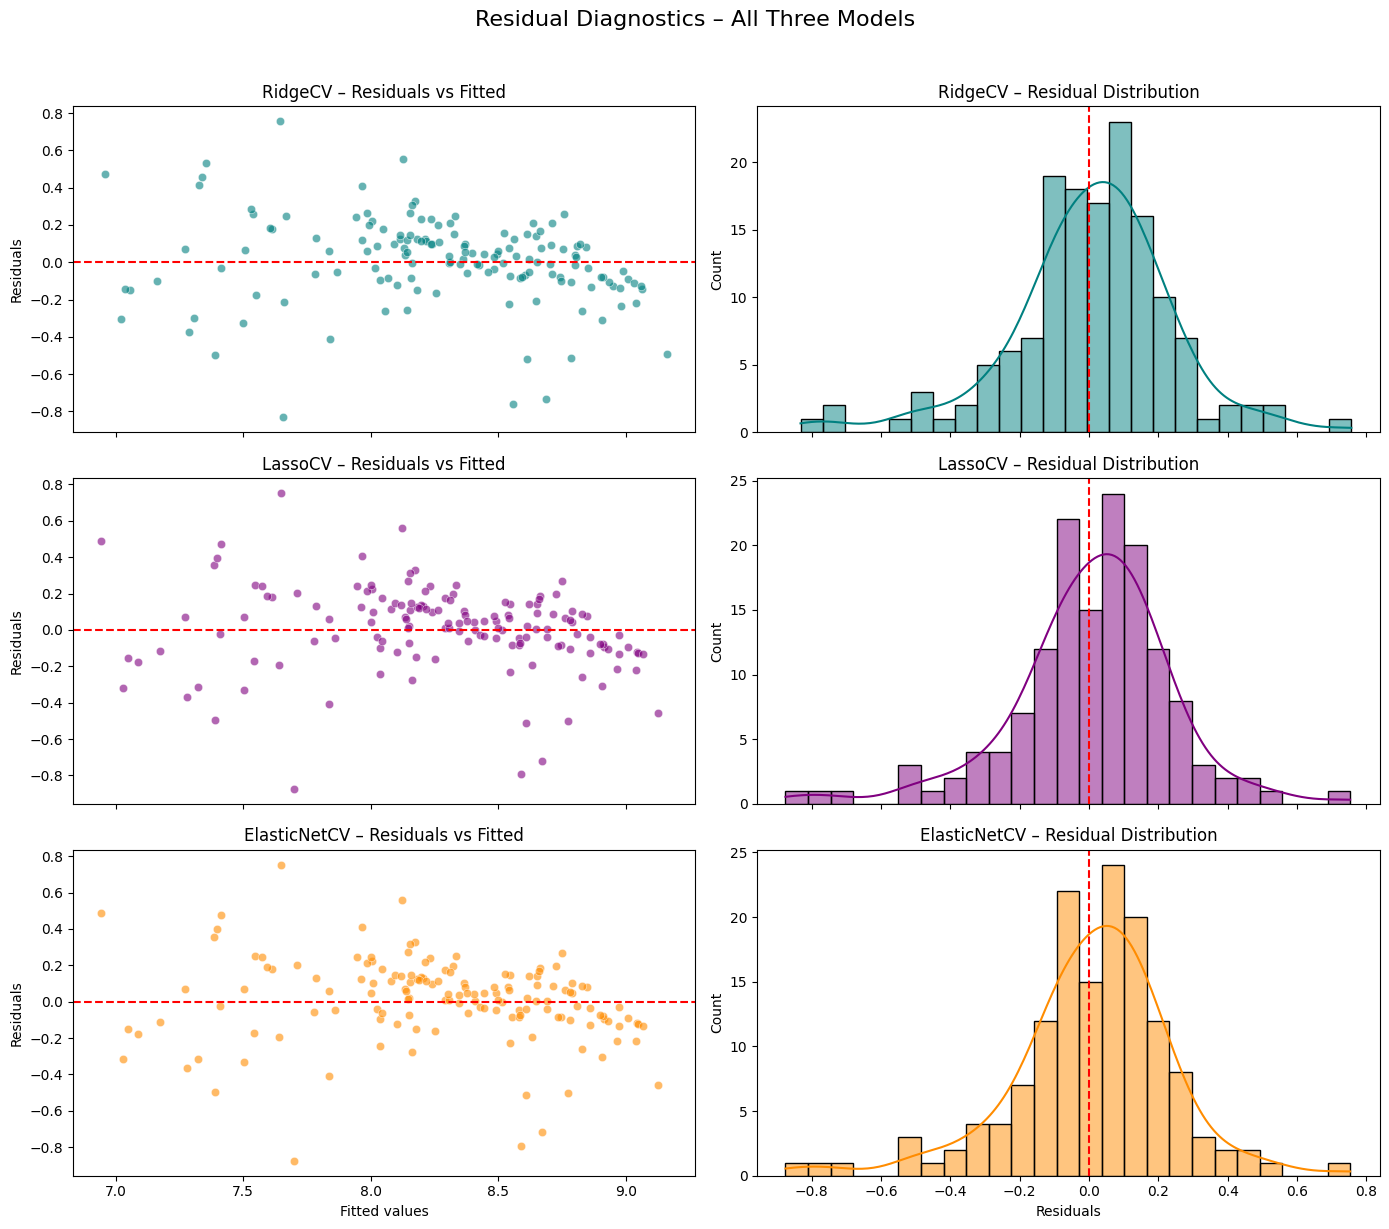

In [42]:
fig, axes = plt.subplots(3, 2, figsize = (14, 12), sharex = 'col')
fig.suptitle("Residual Diagnostics – All Three Models", fontsize = 16, y = 1.02)

for i, (name, model, color) in enumerate([("RidgeCV", ridge_cv, 'teal'), ("LassoCV", lasso_cv, 'purple'), ("ElasticNetCV", elnet_cv, 'darkorange')]):
  preds = model.predict(X_val_final)
  res = y_val - preds

  # Scatter: residuals vs fitted
  sns.scatterplot(x = preds, y = res, ax = axes[i,0], alpha = 0.6, color = color)
  axes[i,0].axhline(0, color = 'red', linestyle = '--')
  axes[i,0].set_title(f"{name} – Residuals vs Fitted")
  axes[i,0].set_xlabel("Fitted values")
  axes[i,0].set_ylabel("Residuals")

  # Histogram + KDE of residuals
  sns.histplot(res, kde = True, ax = axes[i,1], color = color, bins = 25)
  axes[i,1].axvline(0, color = 'red', linestyle = '--')
  axes[i,1].set_title(f"{name} – Residual Distribution")
  axes[i,1].set_xlabel("Residuals")
  axes[i,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [43]:
# Choose the best model (lowest validation RMSE)

models = [("OLS Baseline", rmse_val, r2_score_val), ("RidgeCV", rmse_val_ridge, r2_score_val_ridge),
          ("LassoCV", rmse_val_lasso, r2_score_val_lasso), ("ElasticNetCV", rmse_val_elnet, r2_score_val_elnet)]

# Find model with lowest RMSE
best_name = ""
best_rmse = float('inf')
best_r2 = 0.0

for name, rmse, r2 in models:
  if rmse < best_rmse:
    best_rmse = rmse
    best_r2 = r2
    best_name = name

# Print result
print("\nBest model on validation set:")
print(f"Model: {best_name}")
print(f"RMSE: {best_rmse:.2f}")
print(f"R²: {best_r2:.4f}")


Best model on validation set:
Model: LassoCV
RMSE: 0.23
R²: 0.7977


In [44]:
# Dictionary of all fitted models
model_dict = {"OLS Baseline": ols_model, "RidgeCV": ridge_cv, "LassoCV": lasso_cv, "ElasticNetCV": elnet_cv}

# List of (name, validation RMSE, validation R²)
performance = [("OLS Baseline", rmse_val, r2_score_val), ("RidgeCV", rmse_val_ridge, r2_score_val_ridge),
               ("LassoCV", rmse_val_lasso, r2_score_val_lasso), ("ElasticNetCV", rmse_val_elnet, r2_score_val_elnet)]

# Find the best
best_name = ""
best_rmse = float('inf')
best_r2   = -float('inf')
best_model = None

for name, rmse, r2 in performance:
  if rmse < best_rmse:
    best_rmse = rmse
    best_r2   = r2
    best_name = name
    best_model = model_dict[name]

# Print result
print("\nBest model on validation set:")
print(f"Model: {best_name}")
print(f"RMSE: {best_rmse:.2f}")
print(f"R²: {best_r2:.4f}")

# Safety check
if best_model is None:
    print("ERROR: No model was selected. Check if all RMSE values are defined.")
else:
    print("Best model object is ready for prediction.")


Best model on validation set:
  Model : LassoCV
  RMSE  : 0.23
  R²    : 0.7977
Best model object is ready for prediction.


# **Test Set**

In [45]:
# Final predictions and evaluation on Test Set
print(f"\nSelected final model for predictions: {best_name}")

# Make predictions on the test set
y_test_pred = best_model.predict(X_test_final)

# Calculate metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

# Print results
print(f"MAE for final model: {mae_test:,.2f}")
print(f"MSE for final model: {mse_test:,.2f}")
print(f"RMSE for final model: {rmse_test:,.2f}")
print(f"R² for final model: {r2_test:.4f}")


Selected final model for predictions: LassoCV
MAE for final model: 0.19
MSE for final model: 0.19
RMSE for final model: 0.44
R² for final model: 0.5848


# **Hour Data:**

# **Part A: Data Analysis**

In [46]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [47]:
# Read the dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [48]:
# Print the last 5 rows
df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [49]:
# Print the shape of the dataframe
df.shape

(17379, 17)

In [50]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [51]:
# Data type of the attributes of the dataframe
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [52]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [53]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [54]:
df.keys()

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [55]:
df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


### **The shape of the dataset is (17379, 17). 17379 unique values in the instant/dteday column indicates that each row is a unique entry for Bike Sharing.**

# **Part B: Data Preprocessing**

In [56]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [57]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
instant,0,0.0
dteday,0,0.0
season,0,0.0
yr,0,0.0
mnth,0,0.0
hr,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0


# **The dataset is clean with no duplicates and no missing values!**

In [58]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [59]:
df.rename(columns = {'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'hr': 'hour', 'weathersit': 'weather', 'cnt': 'count'}, inplace = True)
df.head()

,instant,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [60]:
# Drop the redundant features
# df = df.drop(['instant', 'atemp', 'hum', 'windspeed'], axis = 1)
df = df.drop(['instant', 'year', 'month'], axis = 1)
df.head()

,date,season,hour,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,2011-01-01,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [61]:
df['date'] = df['date'].astype('datetime64[ns]')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df.drop('date', axis = 1)
df.head()

,season,hour,holiday,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count,year,month
0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011,1
1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011,1
2,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011,1
3,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011,1
4,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011,1


In [62]:
value_counts_cols = ['season', 'hour', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weather']

rows = []

for col in value_counts_cols:
    vc = df[col].value_counts().reset_index()
    vc.columns = ['value', 'count']
    rows.append(vc)

value_counts_df = pd.concat(rows, keys = value_counts_cols)
value_counts_df

value  count
season     0       3   4496
           1       2   4409
           2       1   4242
           3       4   4232
hour       0      16    730
           1      17    730
           2      15    729
           3      14    729
           4      13    729
           5      12    728
           6      18    728
           7      19    728
           8      20    728
           9      21    728
           10     22    728
           11     23    728
           12      8    727
           13      9    727
           14     10    727
           15      7    727
           16     11    727
           17      0    726
           18      6    725
           19      1    724
           20      5    717
           21      2    715
           22      4    697
           23      3    697
year       0    2012   8734
           1    2011   8645
month      0       7   1488
           1       5   1488
           2      12   1483
           3       8   1475
           4       3   1473
           5      10   1451
           6       6   1440
           7       4   1437
           8       9   1437
           9      11   1437
           10      1   1429
           11      2   1341
holiday    0       0  16879
           1       1    500
weekday    0       6   2512
           1       0   2502
           2       5   2487
           3       1   2479
           4       3   2475
           5       4   2471
           6       2   2453
workingday 0       1  11865
           1       0   5514
weather    0       1  11413
           1       2   4544
           2       3   1419
           3       4      3

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   hour        17379 non-null  int64  
 2   holiday     17379 non-null  int64  
 3   weekday     17379 non-null  int64  
 4   workingday  17379 non-null  int64  
 5   weather     17379 non-null  int64  
 6   temp        17379 non-null  float64
 7   atemp       17379 non-null  float64
 8   hum         17379 non-null  float64
 9   windspeed   17379 non-null  float64
 10  casual      17379 non-null  int64  
 11  registered  17379 non-null  int64  
 12  count       17379 non-null  int64  
 13  year        17379 non-null  int32  
 14  month       17379 non-null  int32  
dtypes: float64(4), int32(2), int64(9)
memory usage: 1.9 MB


# **Part C: Exploratory Data Analysis**

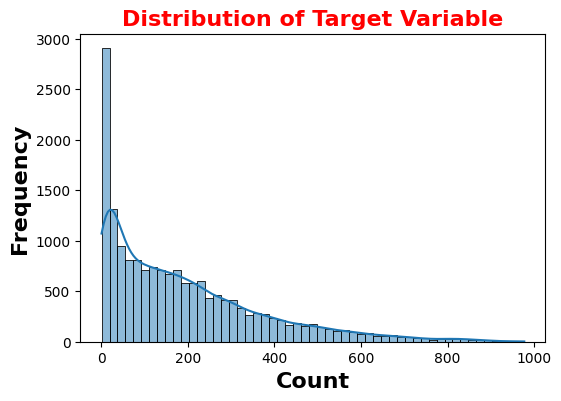

In [64]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.histplot(x = df['count'], kde = True)
plt.title('Distribution of Target Variable', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('Count', fontsize = 16, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 16, fontweight = 'bold')
plt.show()

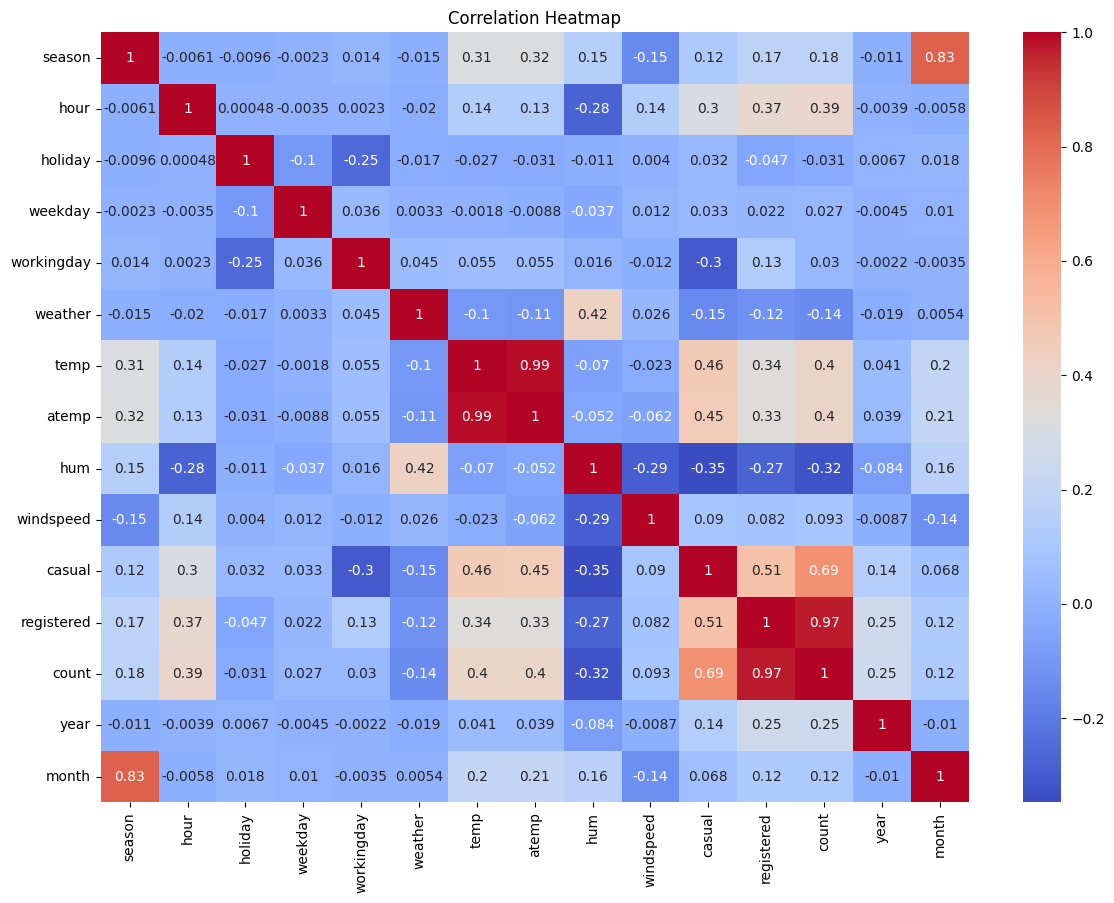

In [65]:
# Heatmap for correlation
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- **High multicollinearity** exists between temp and atemp (corr ≈ 0.99) and between season and month (corr ≈ 0.83), suggesting one from each pair can be dropped in simple models.

- **Strongest predictors** of count are registered (≈ 0.97), casual (≈ 0.69), temp/atempyear (≈ 0.4), and hour (≈ 0.39).

- casual (≈ 0.69) and registered (≈ 0.97) show very **high correlation** with count as they are direct components → must be excluded to prevent leakage.

- **Other features** like holiday, weekday, and workingday have mostly weak correlations with the target and other variables, but remain useful in combination with regularization.

## **Drop:**

✅ atemp

✅ casual

✅ registered

## **Keep:**

✅ month

✅ season

In [66]:
# Drop highly correlated feature atemp while keeping temp and redundant features of casual and registered
df = df.drop(['atemp', 'casual', 'registered'], axis = 1)
df.head()

,season,hour,holiday,weekday,workingday,weather,temp,hum,windspeed,count,year,month
0,1,0,0,6,0,1,0.24,0.81,0.0,16,2011,1
1,1,1,0,6,0,1,0.22,0.80,0.0,40,2011,1
2,1,2,0,6,0,1,0.22,0.80,0.0,32,2011,1
3,1,3,0,6,0,1,0.24,0.75,0.0,13,2011,1
4,1,4,0,6,0,1,0.24,0.75,0.0,1,2011,1


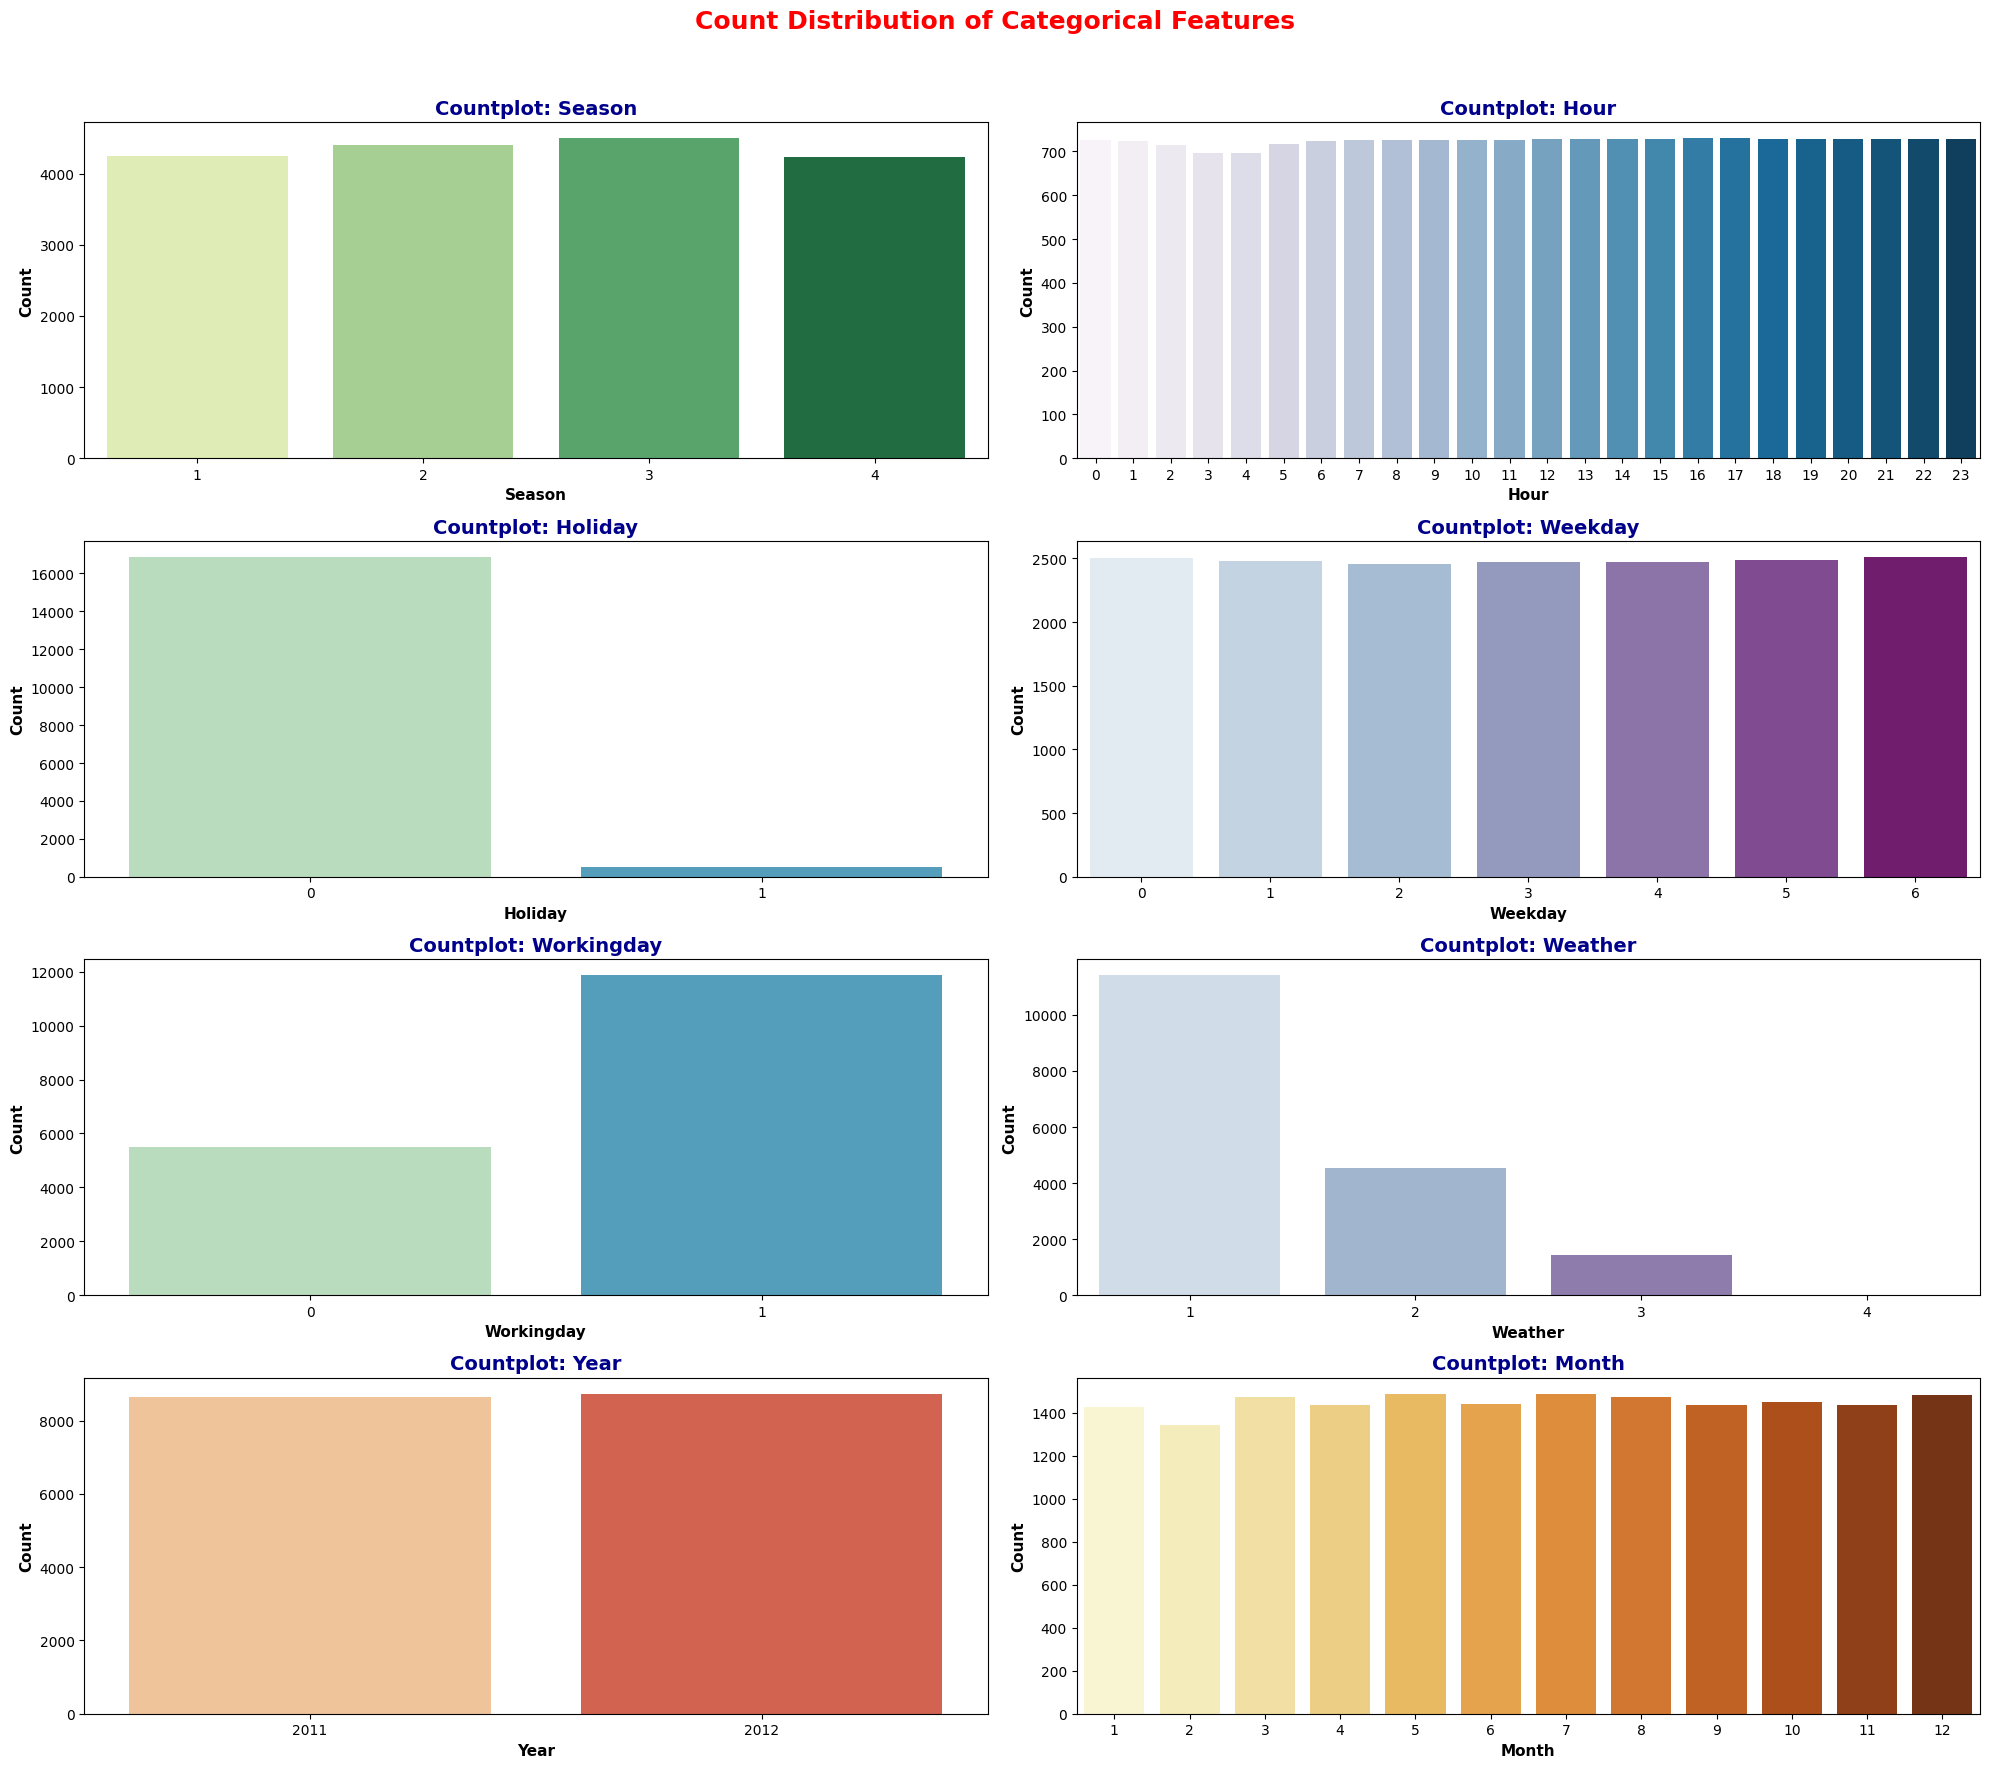

In [67]:
# Countplot of Categorical Features
features = ['season', 'hour', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month']

# Color palettes for each subplot
color_palettes = ['YlGn', 'PuBu', 'GnBu', 'BuPu', 'GnBu', 'BuPu', 'OrRd', 'YlOrBr']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (20, 18))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    sns.countplot(data = df, x = feature, ax = ax, palette = palette)
    ax.set_title(f'Countplot: {feature.replace("_", " ").title()}', fontsize = 14, fontweight = 'bold', color = 'darkblue')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize = 11, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 11, fontweight = 'bold')
    ax.tick_params(axis = 'x')

# Hide unused subplots if any
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Count Distribution of Categorical Features', fontsize = 18, fontweight = 'bold', color = 'red')
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

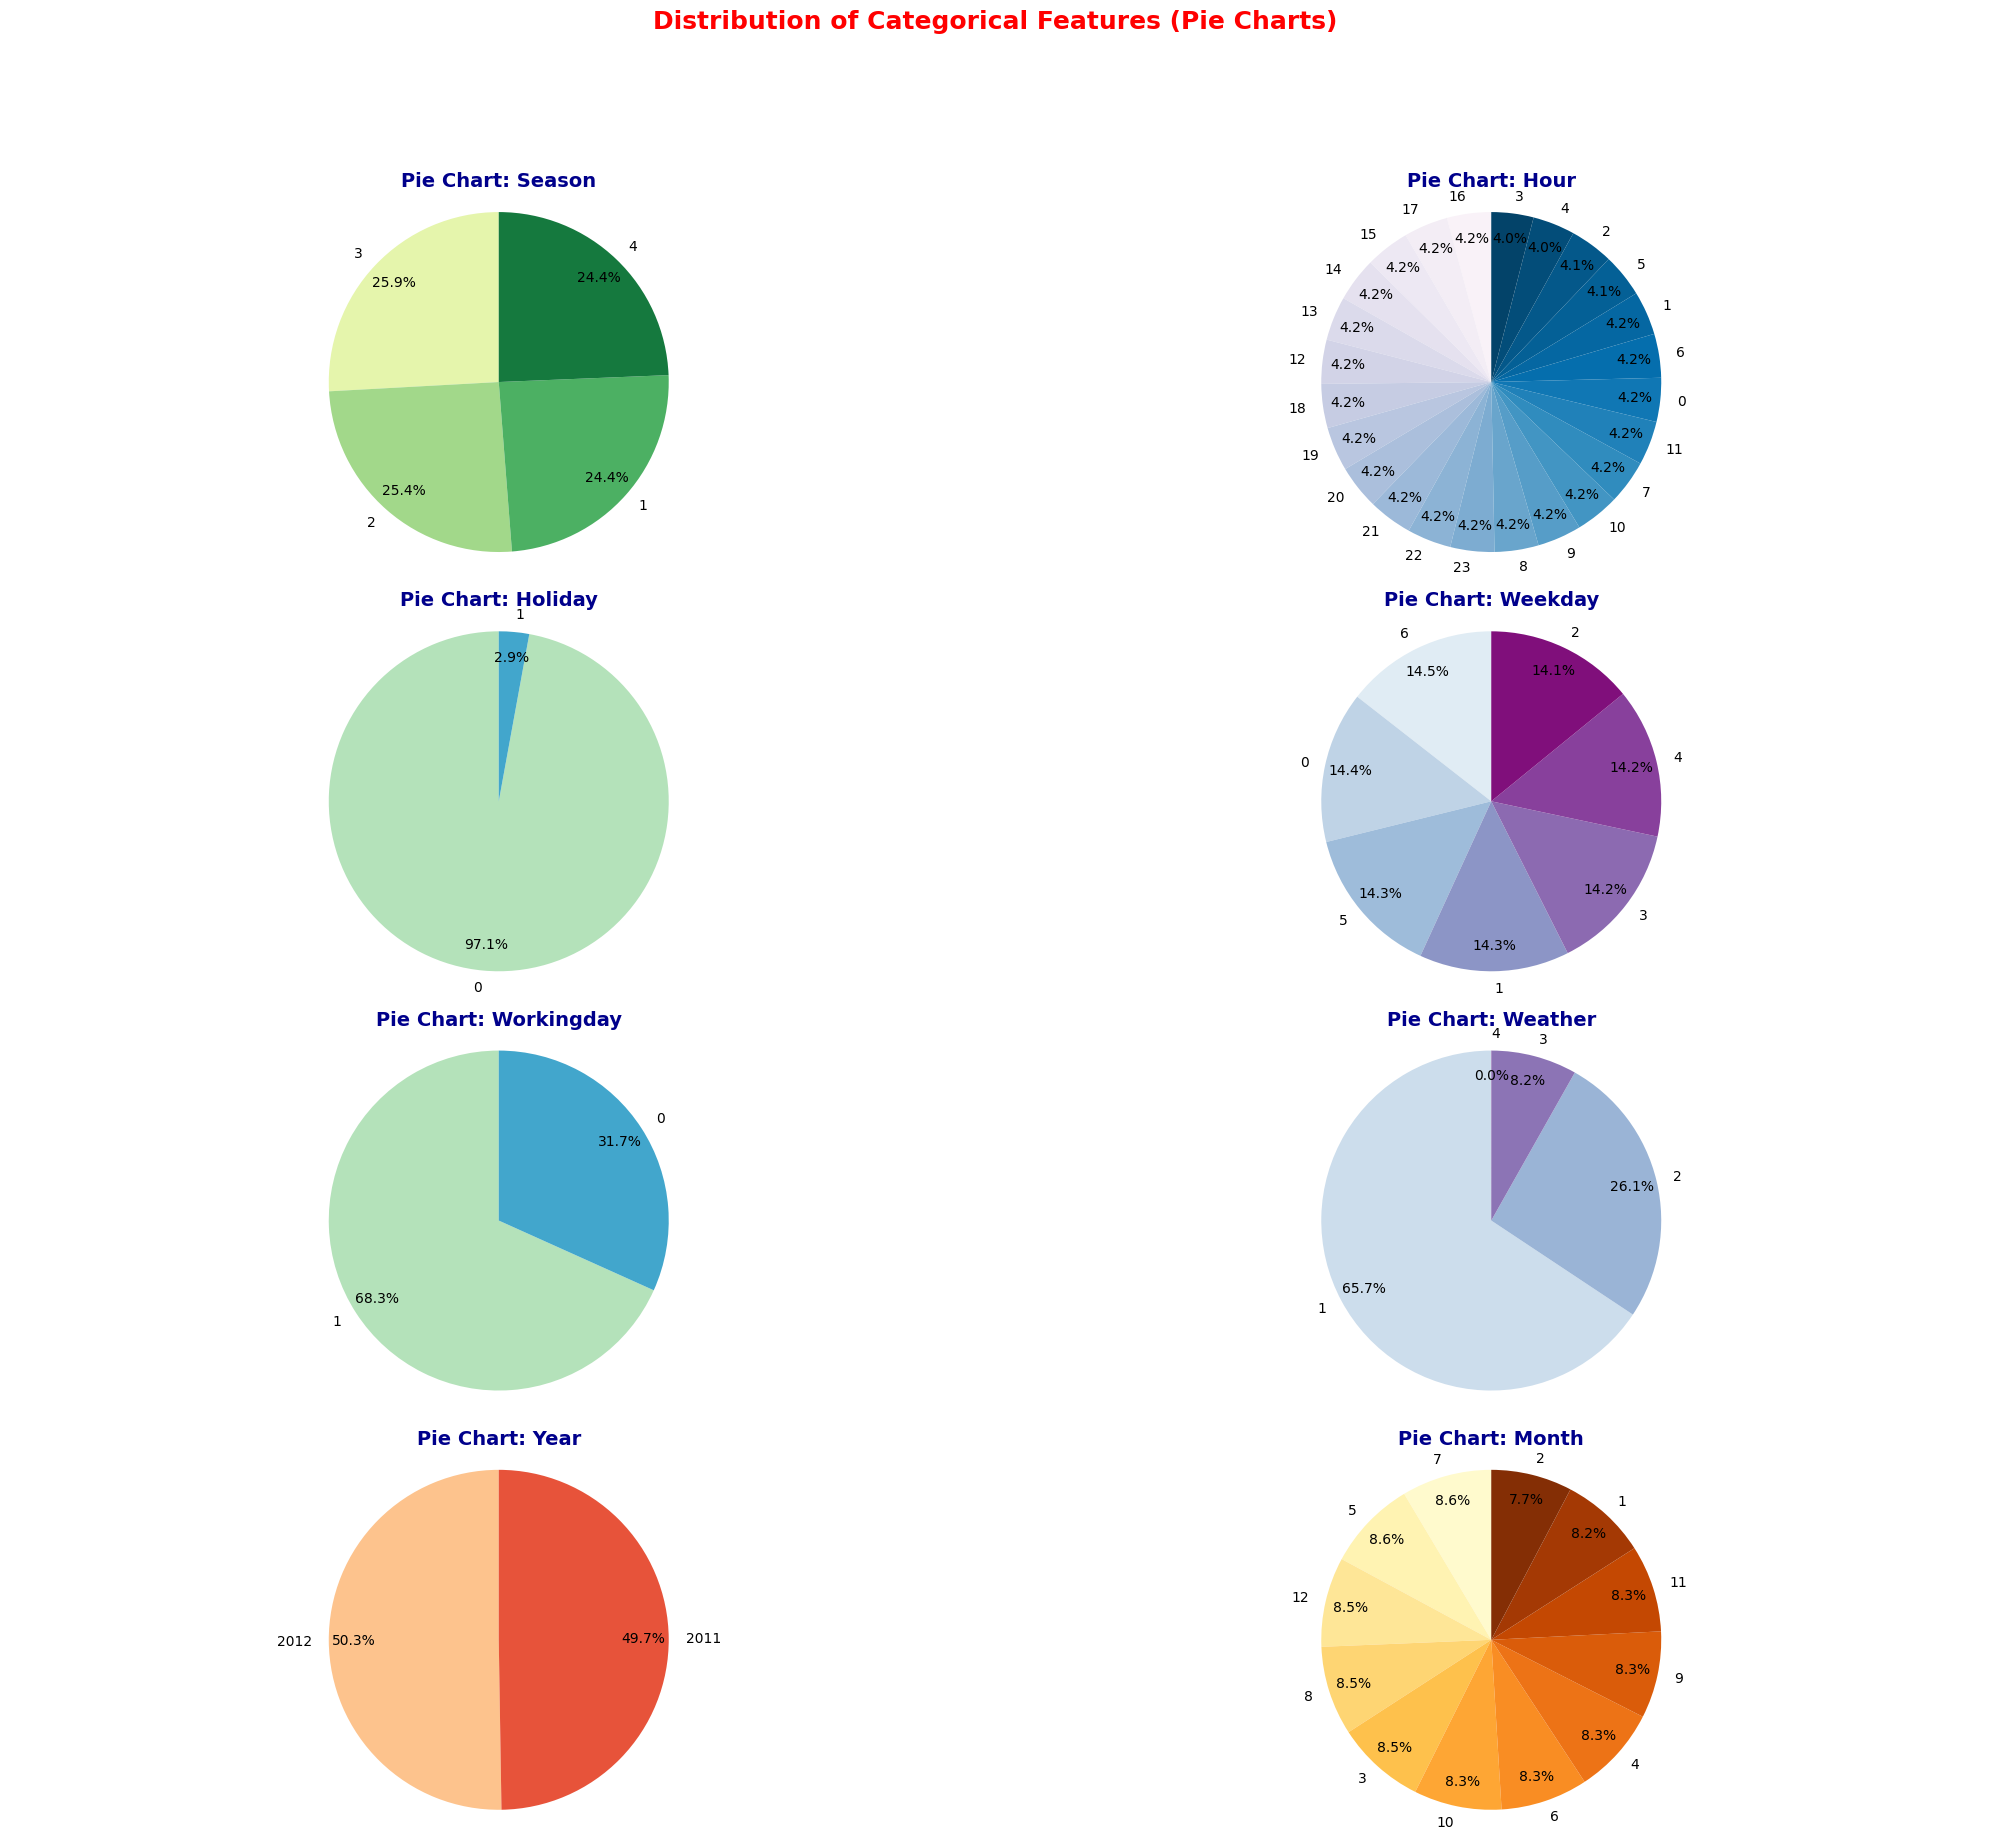

In [68]:
# Countplot of Categorical Features
features = ['season', 'hour', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month']

# Color palettes for each subplot
color_palettes = ['YlGn', 'PuBu', 'GnBu', 'BuPu', 'GnBu', 'BuPu', 'OrRd', 'YlOrBr']

# 4 rows × 2 columns grid
fig, axes = plt.subplots(4, 2, figsize = (20, 18))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    # Get value counts and labels
    value_counts = df[feature].value_counts()
    labels = value_counts.index
    sizes = value_counts.values

    # Choose colors from palette
    colors = sns.color_palette(palette, n_colors = len(labels))

    # Pie chart
    ax.pie(sizes, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 90, textprops = {'fontsize': 10}, pctdistance = 0.85)

    # Equal aspect ratio ensures pie is circular
    ax.axis('equal')
    ax.set_title(f'Pie Chart: {feature.replace("_", " ").title()}',
                 fontsize = 14, fontweight = 'bold', color = 'darkblue')

# Hide any unused subplots (if fewer than 12 features)
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Categorical Features (Pie Charts)', fontsize = 18, fontweight = 'bold', color = 'red', y = 1.02)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

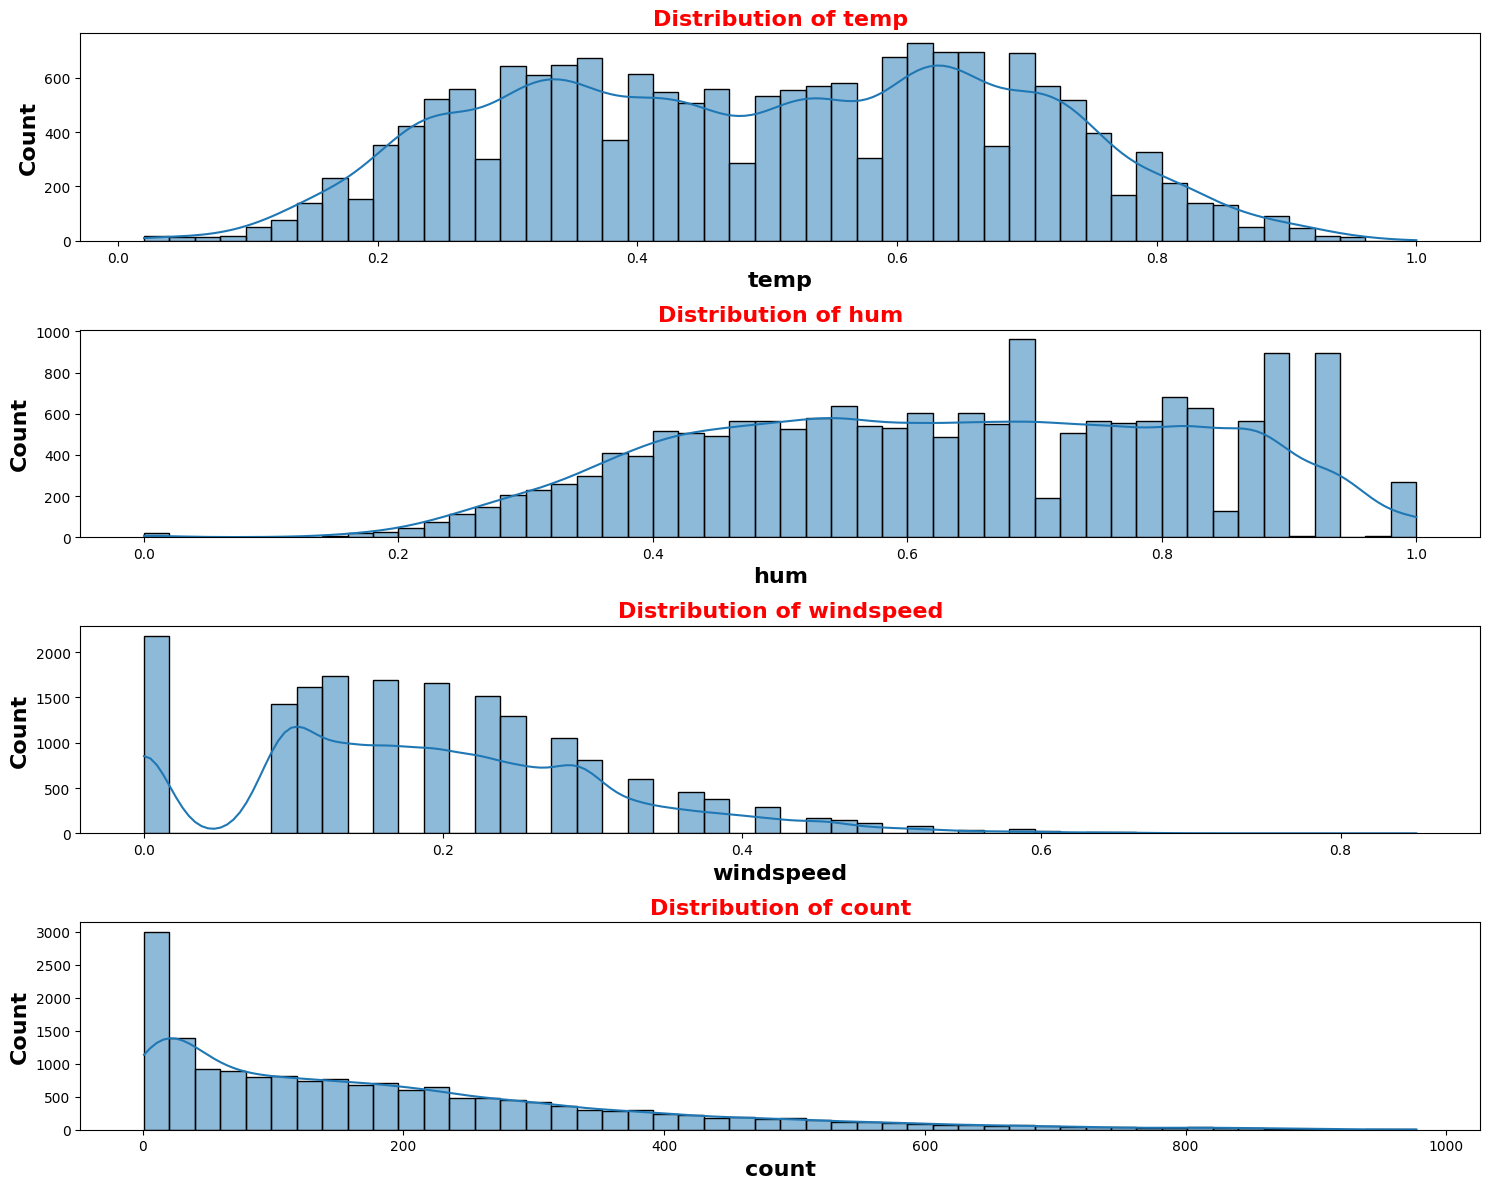

In [69]:
# Histplot for numerical features
features = ['temp', 'hum', 'windspeed', 'count']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 1, i)
    sns.histplot(data = df, x = col, kde = True, bins = 50)
    plt.title(f'Distribution of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

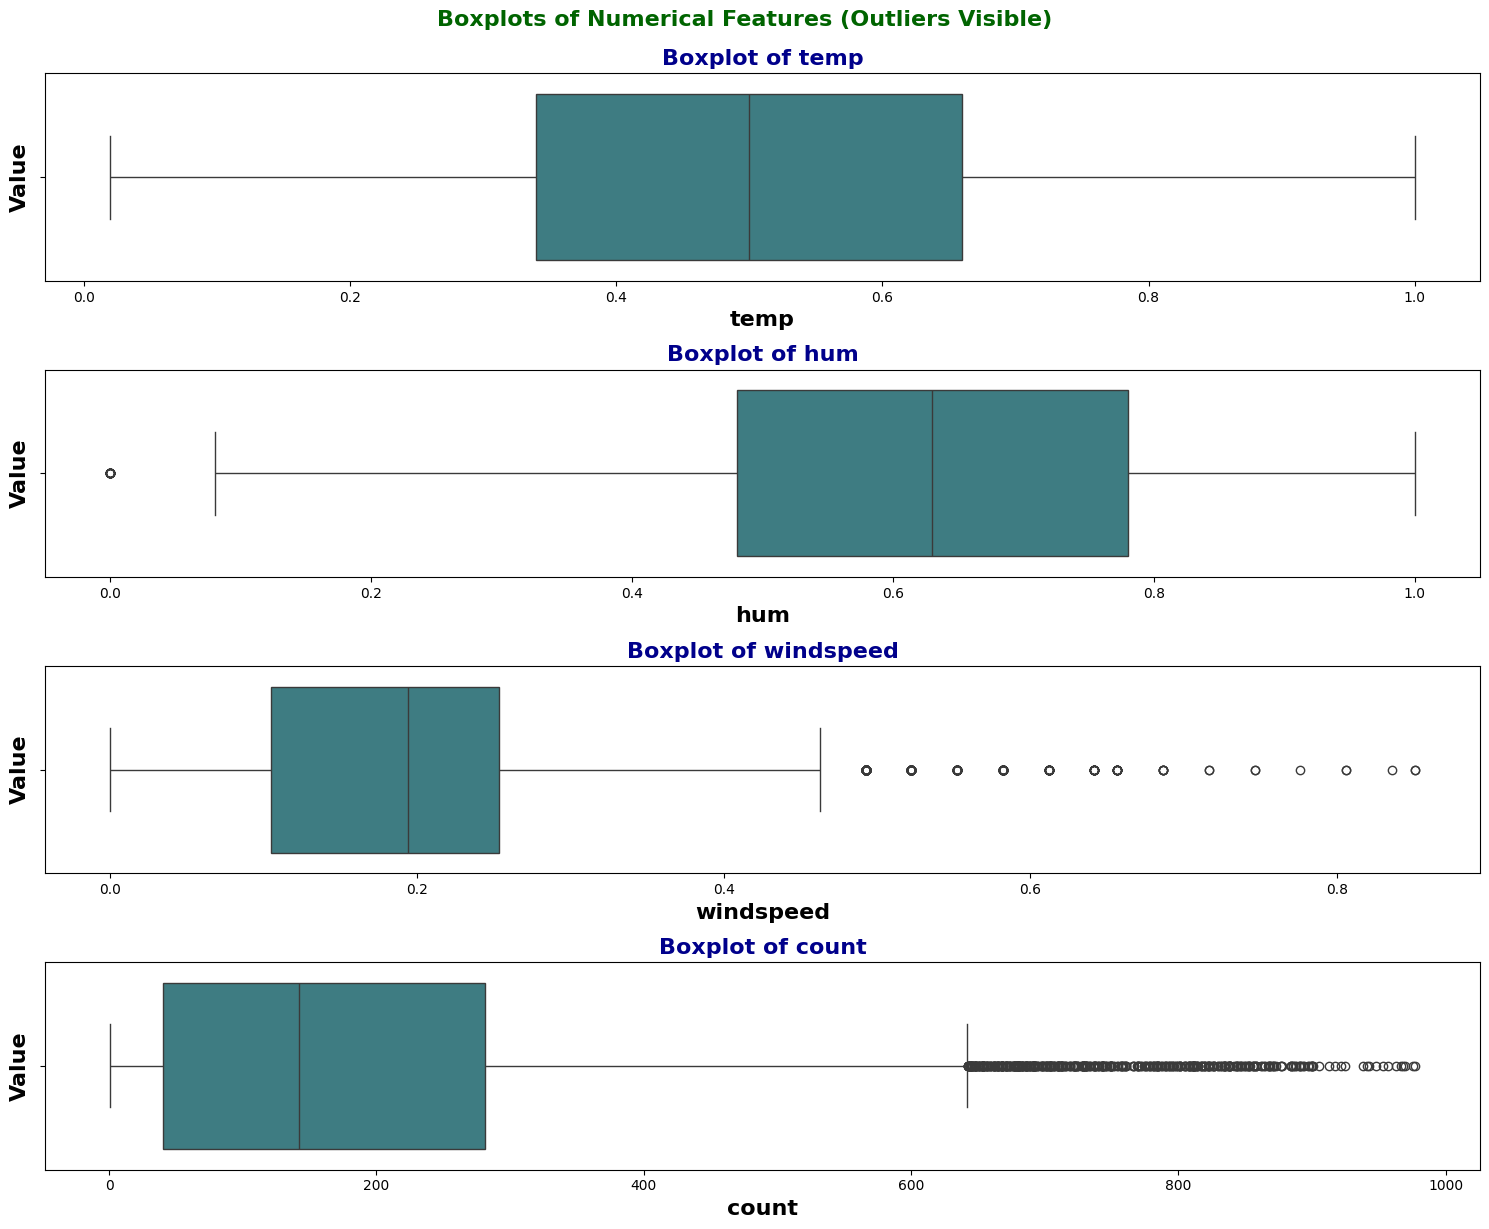

In [70]:
# Boxplot for numerical features
features = ['temp', 'hum', 'windspeed', 'count']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 1, i)
    sns.boxplot(data = df, x = col, orient = 'h', palette = 'crest')
    plt.title(f'Boxplot of {col}', fontsize = 16, fontweight = 'bold', color = 'darkblue')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Value', fontsize = 16, fontweight = 'bold')
    plt.xlabel(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

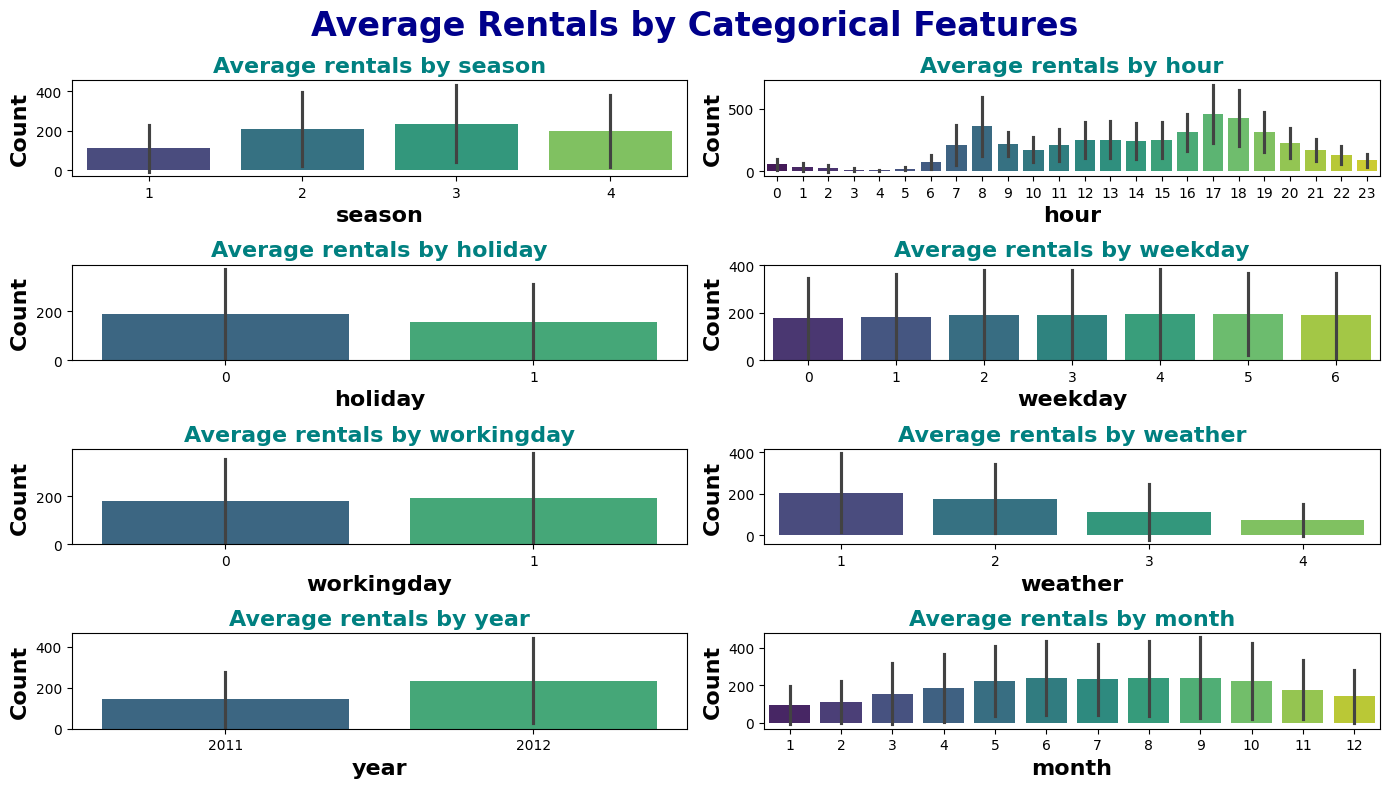

In [71]:
# Barplot (mean/median) + error bars – Categorical vs average count

plt.figure(figsize = (14, 8))
for i, col in enumerate(['season', 'hour', 'holiday', 'weekday', 'workingday', 'weather', 'year', 'month'], 1):
    plt.subplot(4, 2, i)
    sns.barplot(x = col, y = 'count', data = df, estimator = 'mean', errorbar = 'sd', palette = 'viridis')
    plt.title(f'Average rentals by {col}', fontsize = 16, fontweight = 'bold', color = 'teal')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
    plt.suptitle('Average Rentals by Categorical Features', fontsize = 24, fontweight = 'bold', color = 'darkblue')
plt.tight_layout()
plt.show()

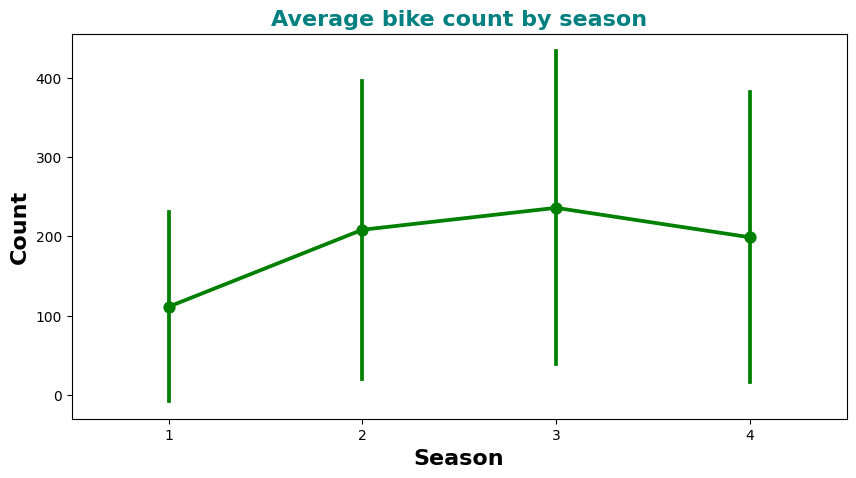

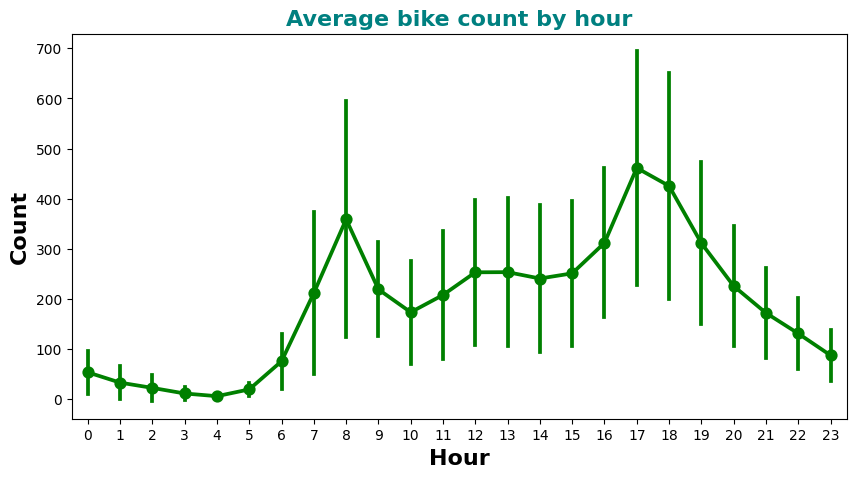

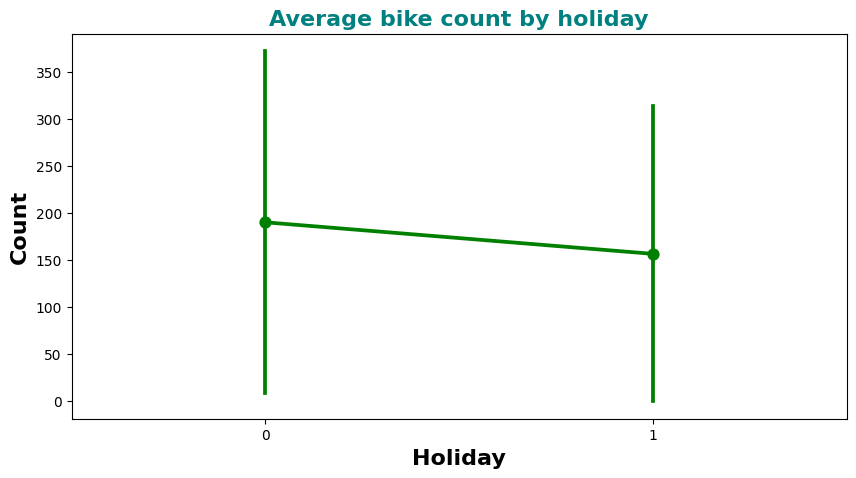

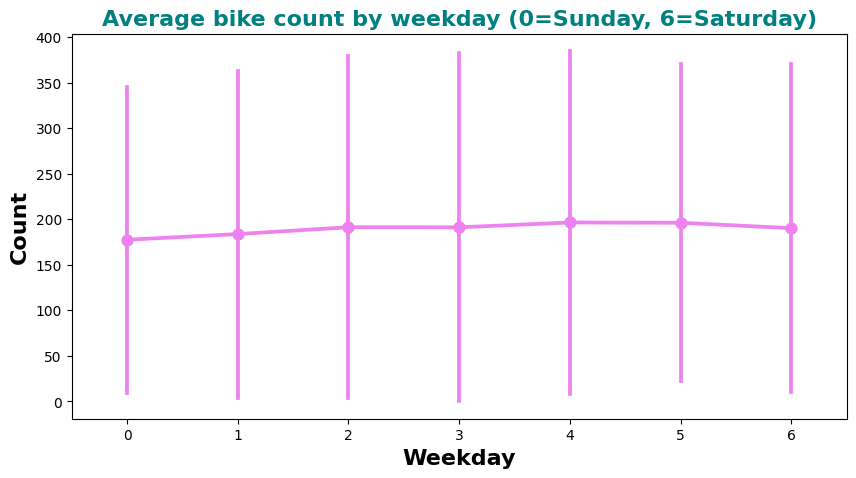

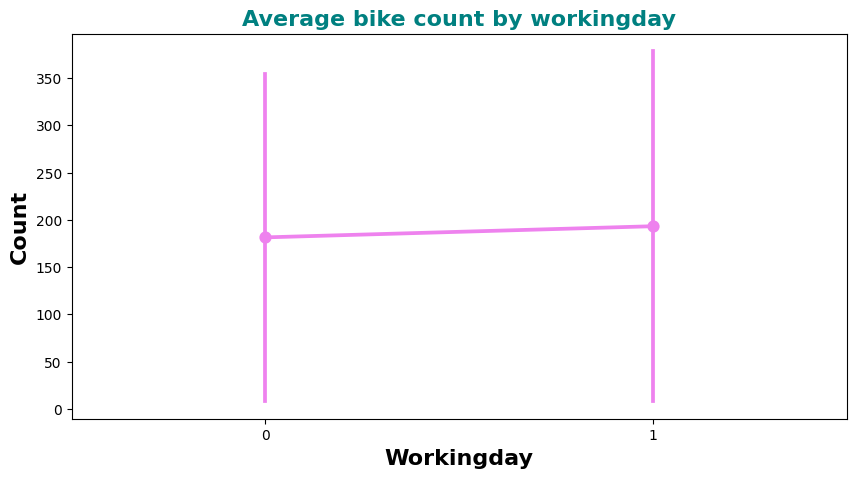

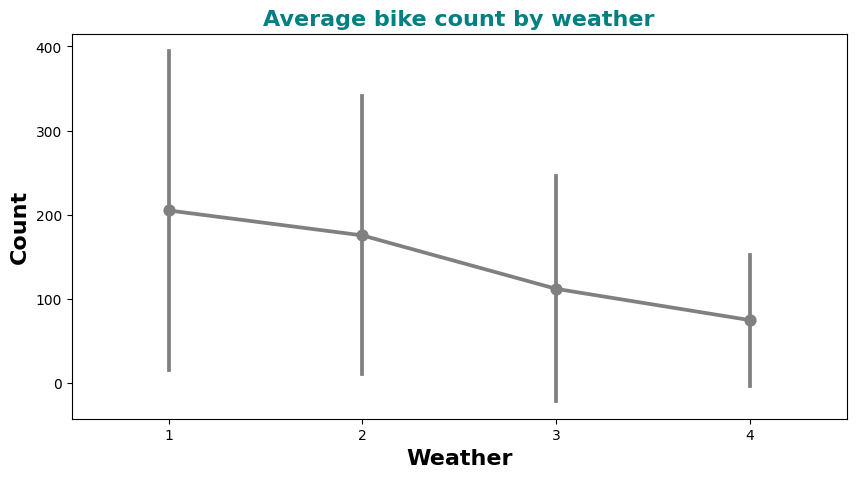

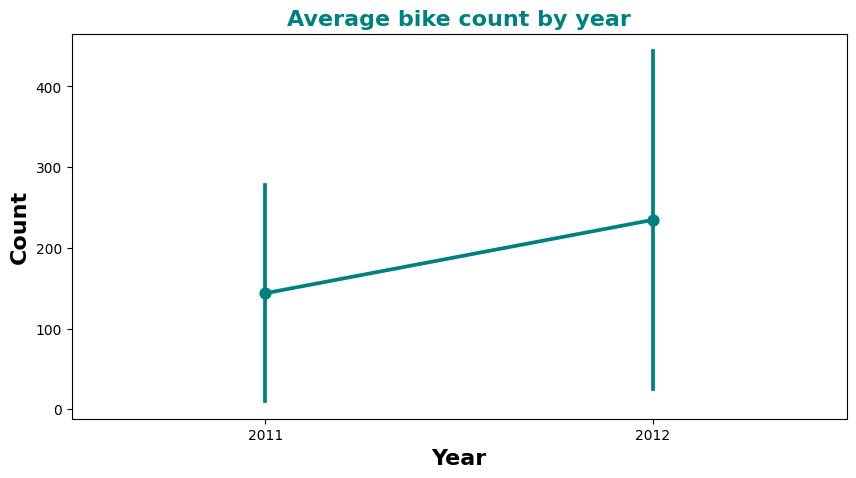

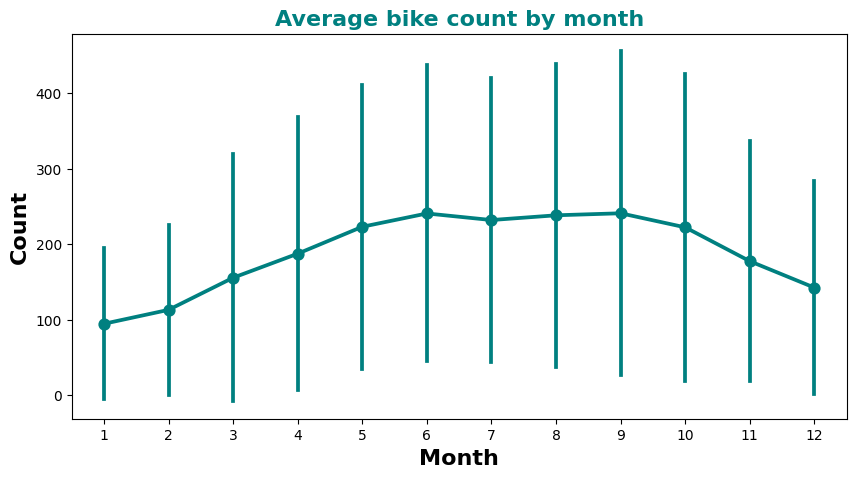

In [72]:
# Pointplot – Ordered categories vs count

# Season pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'season', y = 'count', data = df, errorbar = 'sd', color = 'green')
plt.title("Average bike count by season", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Hour pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'hour', y = 'count', data = df, errorbar = 'sd', color = 'green')
plt.title("Average bike count by hour", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Hour", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Holiday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'holiday', y = 'count', data = df, errorbar = 'sd', color = 'green')
plt.title("Average bike count by holiday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Holiday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Weekday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'weekday', y = 'count', data = df, errorbar = 'sd', color = 'violet')
plt.title("Average bike count by weekday (0=Sunday, 6=Saturday)", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Weekday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Workingday pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'workingday', y = 'count', data = df, errorbar = 'sd', color = 'violet')
plt.title("Average bike count by workingday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Workingday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Weather pattern
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'weather', y = 'count', data = df, errorbar = 'sd', color = 'grey')
plt.title("Average bike count by weather", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Weather", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Year trend
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'year', y = 'count', data = df, errorbar = 'sd', color = 'teal')
plt.title("Average bike count by year", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Year", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Month trend
plt.figure(figsize = (10, 5))
sns.pointplot(x = 'month', y = 'count', data = df, errorbar = 'sd', color = 'teal')
plt.title("Average bike count by month", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Month", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

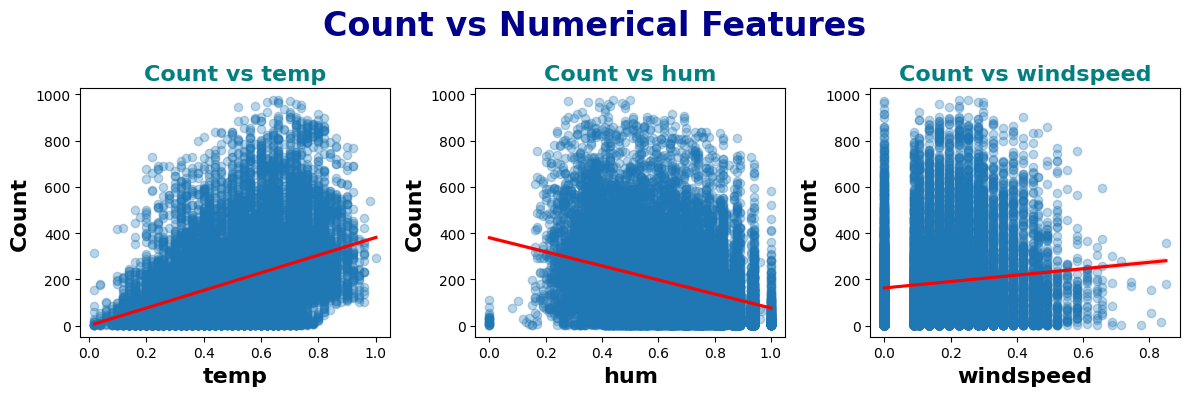

In [73]:
# Scatter + regression line – Numerical features vs countPython
num_features = ['temp', 'hum', 'windspeed']

plt.figure(figsize = (12, 4))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i+1)
    sns.regplot(x = col, y = 'count', data = df, scatter_kws = {'alpha':0.3}, line_kws = {'color':'red'})
    plt.title(f'Count vs {col}', fontsize = 16, fontweight = 'bold', color = 'teal')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.suptitle('Count vs Numerical Features', fontsize = 24, fontweight = 'bold', color = 'darkblue')
plt.tight_layout()
plt.show()

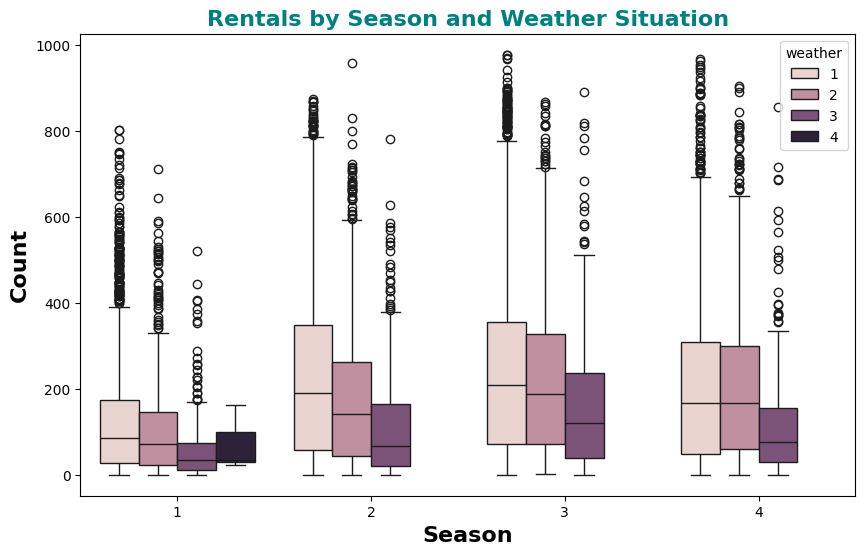

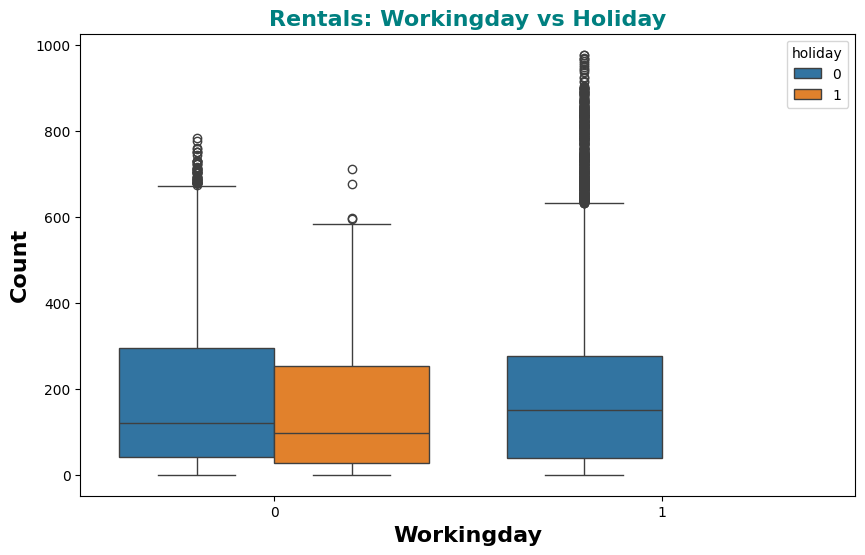

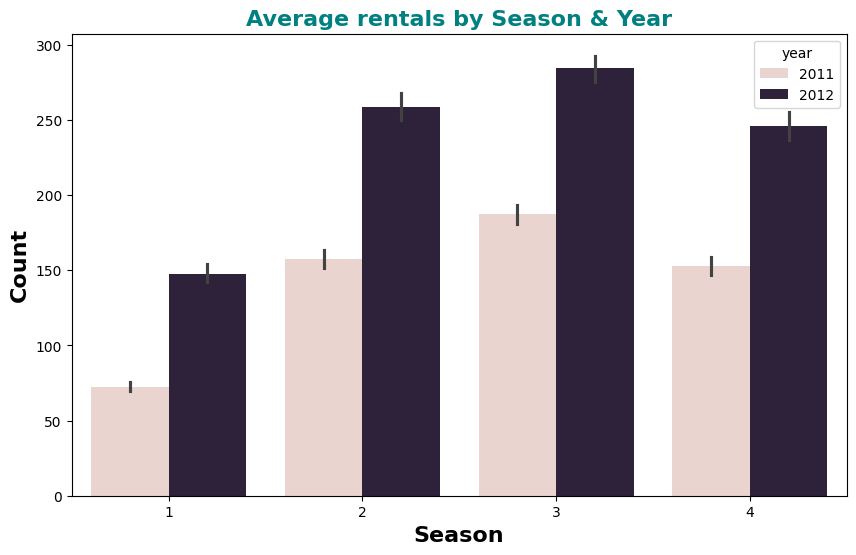

In [74]:
# Boxplot or barplot grouped by two variables
# Season × Weather
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'season', y = 'count', hue = 'weather', data = df)
plt.title("Rentals by Season and Weather Situation", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Workingday × Holiday
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'workingday', y = 'count', hue = 'holiday', data = df)
plt.title("Rentals: Workingday vs Holiday", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Workingday", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

# Season × Year
plt.figure(figsize = (10, 6))
sns.barplot(x = 'season', y = 'count', hue = 'year', data = df, estimator = 'mean')
plt.title("Average rentals by Season & Year", fontsize = 16, fontweight = 'bold', color = 'teal')
plt.xlabel("Season", fontsize = 16, fontweight = 'bold')
plt.ylabel("Count", fontsize = 16, fontweight = 'bold')
plt.show()

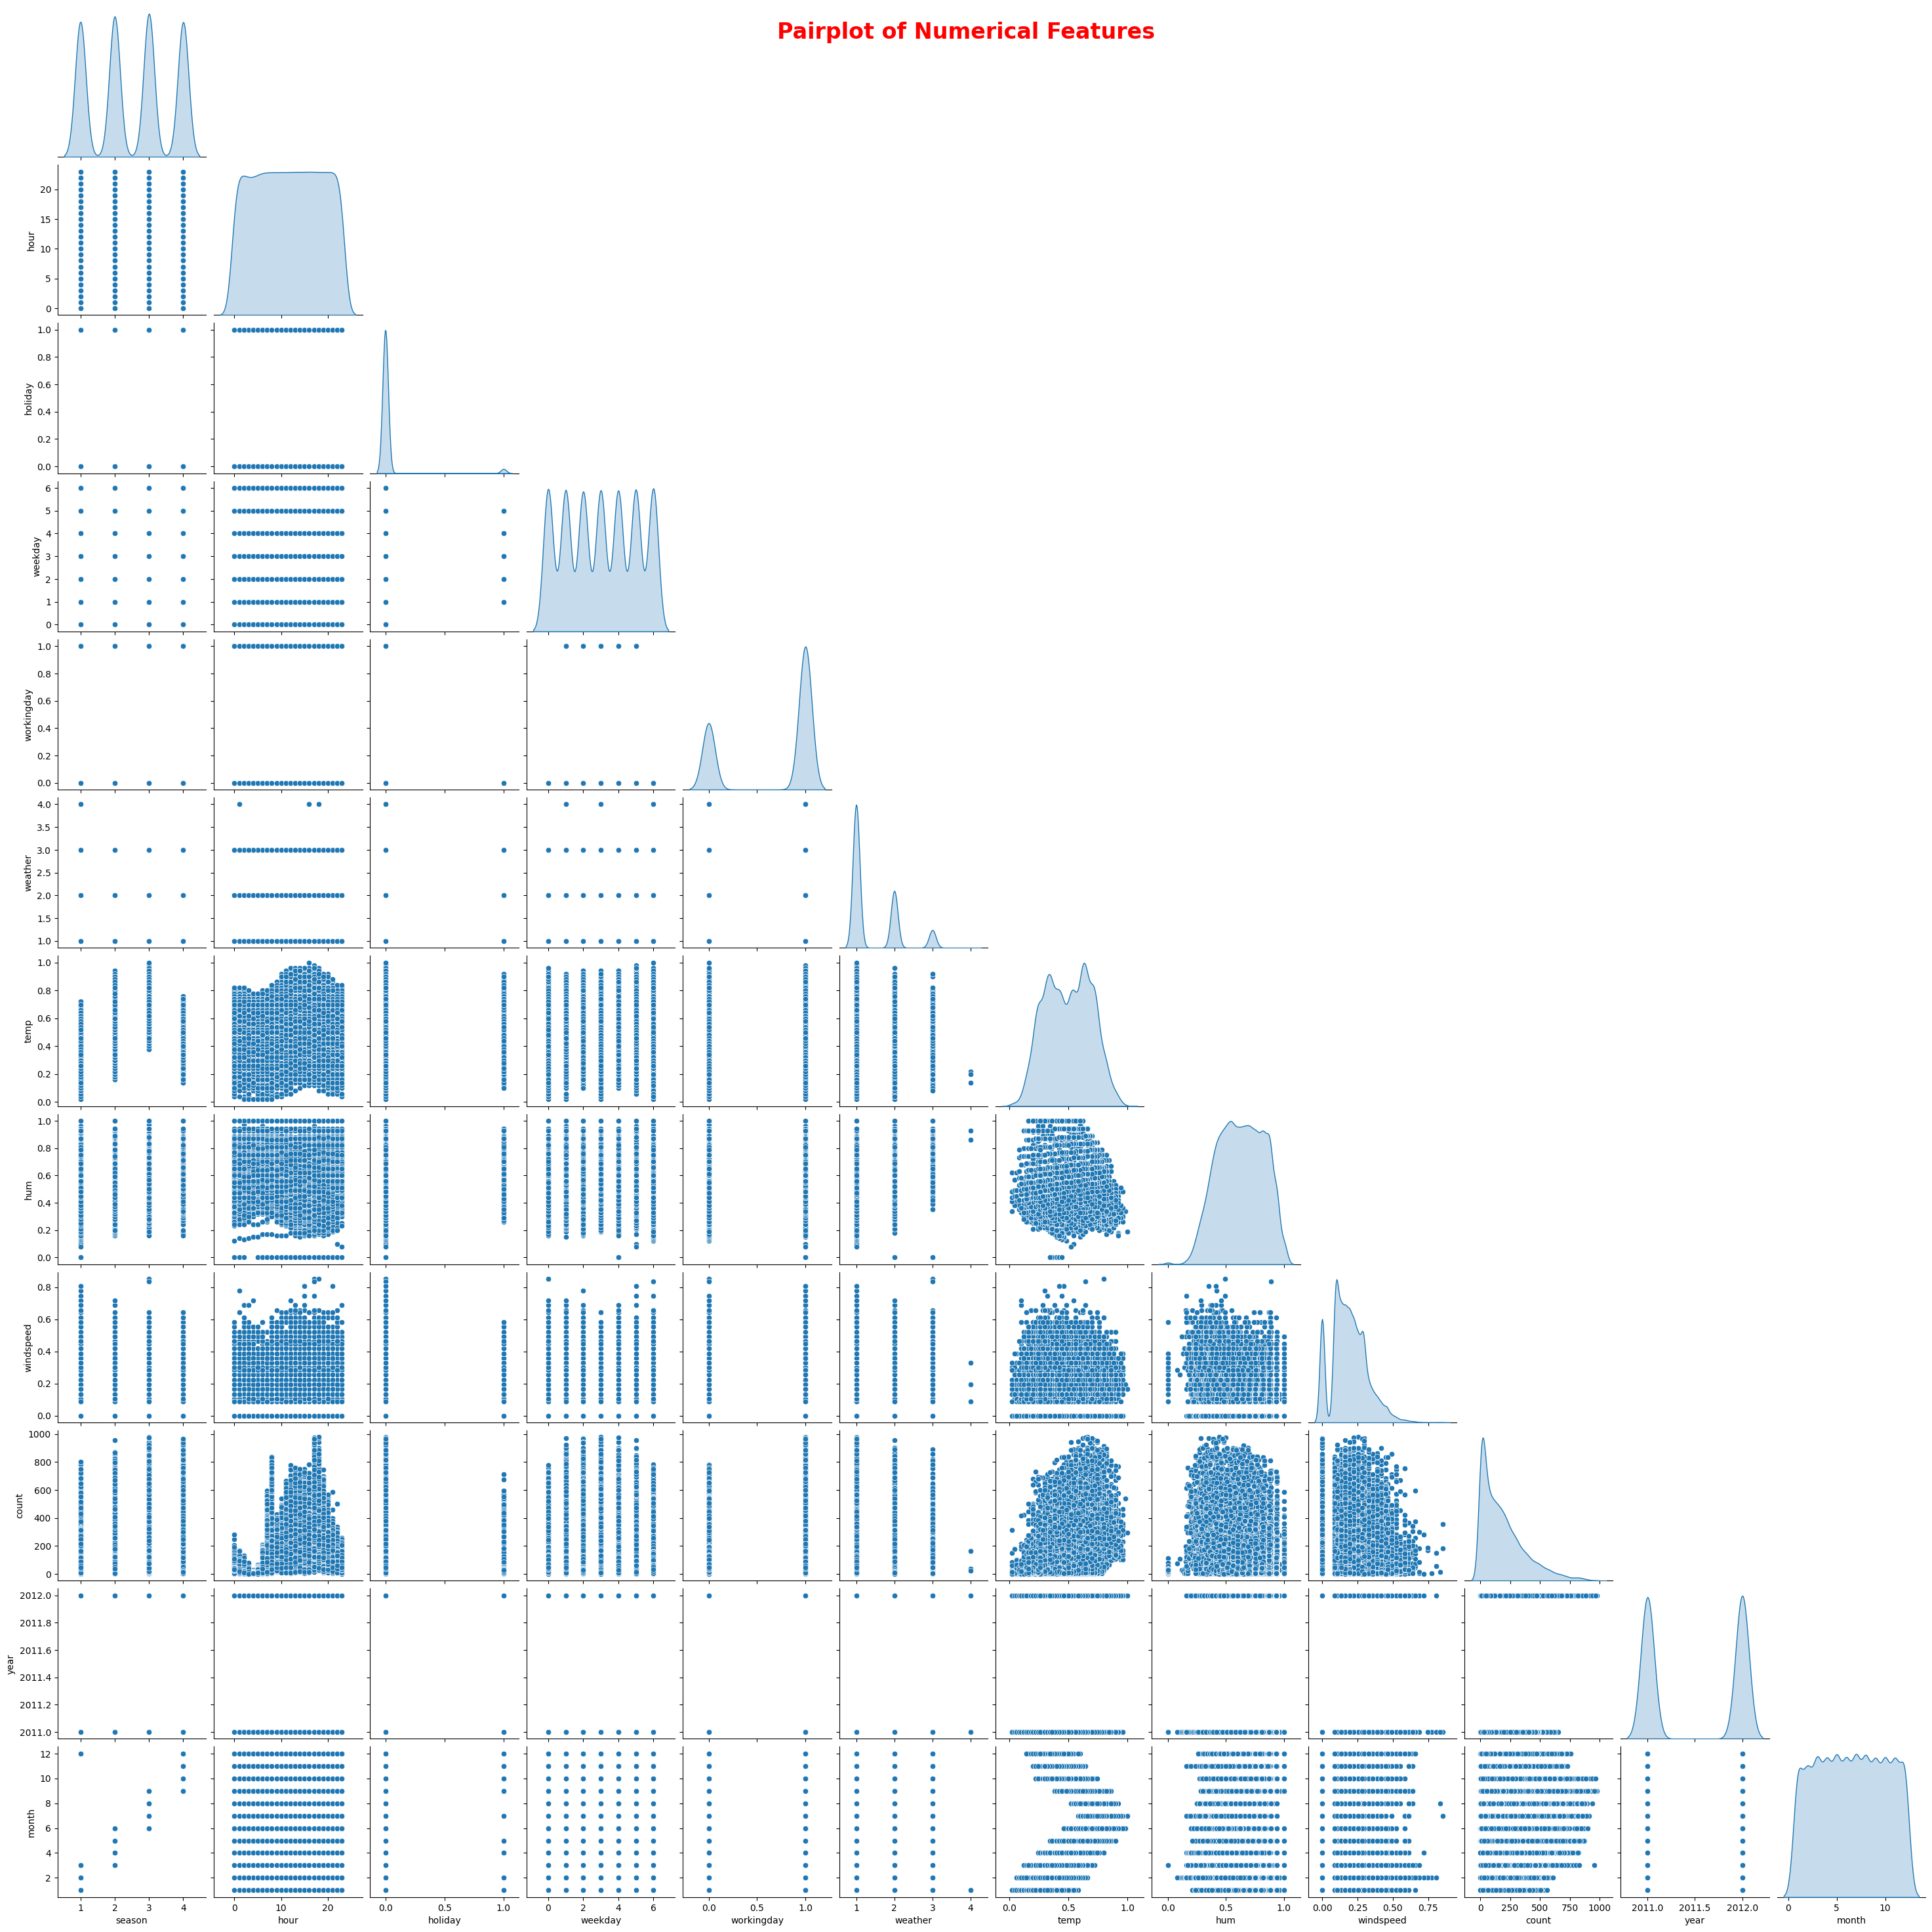

In [75]:
# Pairplot
sns.pairplot(df, diag_kind = 'kde', corner = True)
plt.suptitle('Pairplot of Numerical Features', fontsize = 24, fontweight = 'bold', color = 'red')
plt.show()

# **Linear Regression Model**

# **A: Import the required libraries**

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# **B: Load & prepare data**

In [77]:
X = df.drop('count', axis = 1)
y = df['count']

# Apply log transformation before modeling. Handles right-skew + reduces impact of high outliers
y = np.log1p(y)

# **C: Train Validation Test Split**

# **60% train, 20% validation, 20% test**

In [78]:
# Train Validation Test Split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state = 42)

print(f"Original size: {len(X):4d} rows")
print(f"Train size: {len(X_train):4d} rows")
print(f"Validation size: {len(X_val):4d} rows")
print(f"Test size: {len(X_test):4d} rows")

Original size: 17379 rows
Train size: 10427 rows
Validation size: 3476 rows
Test size: 3476 rows


# **D: Missing values and Outliers Treatment**

The boxplots of numerical features (`temp`, `hum`, `windspeed`, `count`) show a few potential outliers, particularly:
- A small number of very low values in `hum`
- Several high values in `windspeed`
- Multiple high outliers in the target variable `count` (likely legitimate peak demand days).

Given the dataset size, removing or heavily modifying outliers risks losing valuable information, especially since extreme values in bike rentals often correspond to real-world events (e.g., exceptionally good weather, holidays, or special days).

Linear regression (especially with Ridge regularization) is reasonably robust to moderate outliers, and log-transforming the target variable further reduces their influence.

Therefore, **no rows will be removed**, and no aggressive clipping will be applied at this stage. Instead:
- We will apply **log transformation** to the target (`count`) to handle right-skewness and reduce outlier impact.
- Regularization (Ridge) will help stabilize the model.

The dataset is clean with **no missing values**.

Below is the code used to quantify the number of outliers using the IQR method (with 1.5× and 3× IQR thresholds for reference).

In [79]:
def count_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), outliers.index.tolist()

# Features to check
num_cols = ['temp', 'hum', 'windspeed', 'count']

print("Outlier counts using IQR method:\n")
for col in num_cols:
    count_1_5, idx_1_5 = count_outliers_iqr(df[col], multiplier=1.5)
    count_3_0, idx_3_0 = count_outliers_iqr(df[col], multiplier=3.0)

    print(f"{col}:")
    print(f"  • {count_1_5} outliers at 1.5 × IQR ({count_1_5 / len(df):.1%} of data)")
    print(f"  • {count_3_0} outliers at 3.0 × IQR  ({count_3_0 / len(df):.1%} of data)")
    print()

Outlier counts using IQR method:

temp:
  • 0 outliers at 1.5 × IQR (0.0% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)

hum:
  • 22 outliers at 1.5 × IQR (0.1% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)

windspeed:
  • 342 outliers at 1.5 × IQR (2.0% of data)
  • 10 outliers at 3.0 × IQR  (0.1% of data)

count:
  • 505 outliers at 1.5 × IQR (2.9% of data)
  • 0 outliers at 3.0 × IQR  (0.0% of data)



# **E: Encoding and Scaling**

In [80]:
# Encoding

onehot_cols = ['season', 'month', 'weekday', 'weather', 'hour']
encoder = OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore')

# Fit ONLY on train
encoder.fit(X_train[onehot_cols])

# Transform all sets
X_train_onehot = encoder.transform(X_train[onehot_cols])
X_val_onehot = encoder.transform(X_val[onehot_cols])
X_test_onehot = encoder.transform(X_test[onehot_cols])

X_train_onehot = pd.DataFrame(X_train_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_train.index)
X_val_onehot = pd.DataFrame(X_val_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_val.index)
X_test_onehot = pd.DataFrame(X_test_onehot, columns = encoder.get_feature_names_out(onehot_cols), index = X_test.index)

In [81]:
# Scaling

scale_cols  = ['temp', 'hum', 'windspeed']
scaler = StandardScaler()

# Fit ONLY on train
scaler.fit(X_train[scale_cols])

# Transform all sets
X_train_scaled = pd.DataFrame(scaler.transform(X_train[scale_cols]), index = X_train.index, columns = scale_cols)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val[scale_cols]), index = X_val.index, columns = scale_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test[scale_cols]), index = X_test.index, columns = scale_cols)

In [82]:
binary_cols = ['holiday', 'workingday', 'year']

X_train_final = pd.concat([X_train_onehot, X_train_scaled, X_train[binary_cols]], axis = 1)
X_val_final = pd.concat([X_val_onehot, X_val_scaled, X_val[binary_cols]], axis = 1)
X_test_final = pd.concat([X_test_onehot, X_test_scaled, X_test[binary_cols]], axis = 1)

# **F: Multiple Linear Regression Models**

1. Baseline: Multiple Linear Regression (OLS)
2. Ridge (L2 Regularization)
3. Lasso (L1 Regularization)
4. ElasticNet (L1 + L2 Mix)

# **1. Baseline: Multiple Linear Regression (OLS)**

In [83]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train_final)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary(),"\n")

# Predict & evaluate on train set and validation set
X_train_sm = sm.add_constant(X_train_final, has_constant = 'add')
y_train_pred = ols_model.predict(X_train_sm)
X_val_sm = sm.add_constant(X_val_final, has_constant = 'add')
y_val_pred = ols_model.predict(X_val_sm)

# Training set Evaluation
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_score_train = r2_score(y_train, y_train_pred)

print(f"MAE of Baseline Model: {mae_train:,.2f}")
print(f"MSE of Baseline Model: {mse_train:,.2f}")
print(f"RMSE of Baseline Model: {rmse_train:,.2f}")
print(f"R² of Baseline Model: {r2_score_train:.4f}")

# Validation set Evaluation
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_score_val = r2_score(y_val, y_val_pred)

print(f"MAE of Baseline Model: {mae_val:,.2f}")
print(f"MSE of Baseline Model: {mse_val:,.2f}")
print(f"RMSE of Baseline Model: {rmse_val:,.2f}")
print(f"R² of Baseline Model: {r2_score_val:.4f}")

# Show key stats from statsmodels summary
print("\nBaseline Linear Regression OLS Model Summary Highlights:")
print(f"Overall R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic p-value: {ols_model.f_pvalue:.6f}")
print(f"Number of observations: {ols_model.nobs}")

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     989.7
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        05:00:35   Log-Likelihood:                -9350.3
No. Observations:               10427   AIC:                         1.880e+04
Df Residuals:                   10376   BIC:                         1.917e+04
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -924.2719     23.759    -38.902      0.0

# **2. Ridge (L2 Regularization)**

In [84]:
# Define alpha range
alphas = np.logspace(-4, 3, 100)

# 5-fold CV and ridgecv.fit()
ridge_cv = RidgeCV(alphas = alphas, cv = 5, scoring = 'neg_root_mean_squared_error')
ridge_cv.fit(X_train_final, y_train)

print(f"Best alpha for RidgeCV: {ridge_cv.alpha_:.6f}")
print(f"Best score for RidgeCV: {-ridge_cv.best_score_:.6f}")

# Predictions
y_train_pred_ridge = ridge_cv.predict(X_train_final)
y_val_pred_ridge = ridge_cv.predict(X_val_final)

# Training set Evaluation
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)
r2_score_train_ridge = r2_score(y_train, y_train_pred_ridge)

print(f"MAE of Ridge Model: {mae_train_ridge:,.2f}")
print(f"MSE of Ridge Model: {mse_train_ridge:,.2f}")
print(f"RMSE of Ridge Model: {rmse_train_ridge:,.2f}")
print(f"R² of Ridge Model: {r2_score_train_ridge:.4f}")

# Validation set Evaluation
mae_val_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
mse_val_ridge = mean_squared_error(y_val, y_val_pred_ridge)
rmse_val_ridge = np.sqrt(mse_val_ridge)
r2_score_val_ridge = r2_score(y_val, y_val_pred_ridge)

print(f"MAE of Ridge Model: {mae_val_ridge:,.2f}")
print(f"MSE of Ridge Model: {mse_val_ridge:,.2f}")
print(f"RMSE of Ridge Model: {rmse_val_ridge:,.2f}")
print(f"R² of Ridge Model: {r2_score_val_ridge:.4f}")

Best alpha for RidgeCV: 0.041320
Best score for RidgeCV: 0.596150
MAE of Ridge Model: 0.45
MSE of Ridge Model: 0.35
RMSE of Ridge Model: 0.59
R² of Ridge Model: 0.8267
MAE of Ridge Model: 0.43
MSE of Ridge Model: 0.32
RMSE of Ridge Model: 0.57
R² of Ridge Model: 0.8369


# **3. Lasso (L1 Regularization)**

In [85]:
# Define alpha range
alphas = np.logspace(-4,3,100)   # from 0.0001 to 1000

# 5-fold CV and lassocv.fit()
lasso_cv = LassoCV(alphas = alphas, cv = 5, max_iter = 5000, random_state = 42)
lasso_cv.fit(X_train_final, y_train)

print(f"Best alpha for LassoCV: {lasso_cv.alpha_:.6f}")

# Predictions
y_train_pred_lasso = lasso_cv.predict(X_train_final)
y_val_pred_lasso = lasso_cv.predict(X_val_final)

# Training set Evaluation
mae_train_lasso = mean_absolute_error(y_train, y_train_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
rmse_train_lasso = np.sqrt(mse_train_lasso)
r2_score_train_lasso = r2_score(y_train, y_train_pred_lasso)

print(f"MAE of Lasso Model: {mae_train_lasso:,.2f}")
print(f"MSE of Lasso Model: {mse_train_lasso:,.2f}")
print(f"RMSE of Lasso Model: {rmse_train_lasso:,.2f}")
print(f"R² of Lasso Model: {r2_score_train_lasso:.4f}")

# Validation set Evaluation
mae_val_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
mse_val_lasso = mean_squared_error(y_val, y_val_pred_lasso)
rmse_val_lasso = np.sqrt(mse_val_lasso)
r2_score_val_lasso = r2_score(y_val, y_val_pred_lasso)

print(f"MAE of Lasso Model: {mae_val_lasso:,.2f}")
print(f"MSE of Lasso Model: {mse_val_lasso:,.2f}")
print(f"RMSE of Lasso Model: {rmse_val_lasso:,.2f}")
print(f"R² of Lasso Model: {r2_score_val_lasso:.4f}")

Best alpha for LassoCV: 0.000100
MAE of Lasso Model: 0.45
MSE of Lasso Model: 0.35
RMSE of Lasso Model: 0.59
R² of Lasso Model: 0.8266
MAE of Lasso Model: 0.43
MSE of Lasso Model: 0.32
RMSE of Lasso Model: 0.57
R² of Lasso Model: 0.8370


# **4. ElasticNet (L1 + L2 Mix)**

In [86]:
# Define alpha range
alphas = np.logspace(-4,3,100)   # from 0.0001 to 1000

# 5-fold CV and elasticnetcv.fit()
elnet_cv = ElasticNetCV(alphas = alphas, cv = 5, max_iter = 5000, random_state = 42, l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0])
elnet_cv.fit(X_train_final, y_train)

print(f"Best alpha for ElasticNetCV: {elnet_cv.alpha_:.6f}")
print(f"Best l1_ratio: {elnet_cv.l1_ratio_:.3f}")

# Predictions
y_train_pred_elnet = elnet_cv.predict(X_train_final)
y_val_pred_elnet = elnet_cv.predict(X_val_final)

# Training set Evaluation
mae_train_elnet = mean_absolute_error(y_train, y_train_pred_elnet)
mse_train_elnet = mean_squared_error(y_train, y_train_pred_elnet)
rmse_train_elnet = np.sqrt(mse_train_elnet)
r2_score_train_elnet = r2_score(y_train, y_train_pred_elnet)

print(f"MAE of ElasticNet Model: {mae_train_elnet:,.2f}")
print(f"MSE of ElasticNet Model: {mse_train_elnet:,.2f}")
print(f"RMSE of ElasticNet Model: {rmse_train_elnet:,.2f}")
print(f"R² of ElasticNet Model: {r2_score_train_elnet:.4f}")

# Validation set Evaluation
mae_val_elnet = mean_absolute_error(y_val, y_val_pred_elnet)
mse_val_elnet = mean_squared_error(y_val, y_val_pred_elnet)
rmse_val_elnet = np.sqrt(mse_val_elnet)
r2_score_val_elnet = r2_score(y_val, y_val_pred_elnet)

print(f"MAE of ElasticNet Model: {mae_val_elnet:,.2f}")
print(f"MSE of ElasticNet Model: {mse_val_elnet:,.2f}")
print(f"RMSE of ElasticNet Model: {rmse_val_elnet:,.2f}")
print(f"R² of ElasticNet Model: {r2_score_val_elnet:.4f}")

Best alpha for ElasticNetCV: 0.000100
Best l1_ratio: 1.000
MAE of ElasticNet Model: 0.45
MSE of ElasticNet Model: 0.35
RMSE of ElasticNet Model: 0.59
R² of ElasticNet Model: 0.8266
MAE of ElasticNet Model: 0.43
MSE of ElasticNet Model: 0.32
RMSE of ElasticNet Model: 0.57
R² of ElasticNet Model: 0.8370


In [87]:
# Residual Diagnostics. Residuals = actual - predicted
res_ridge = y_val - y_val_pred_ridge
res_lasso = y_val - y_val_pred_lasso
res_elnet  = y_val - y_val_pred_elnet

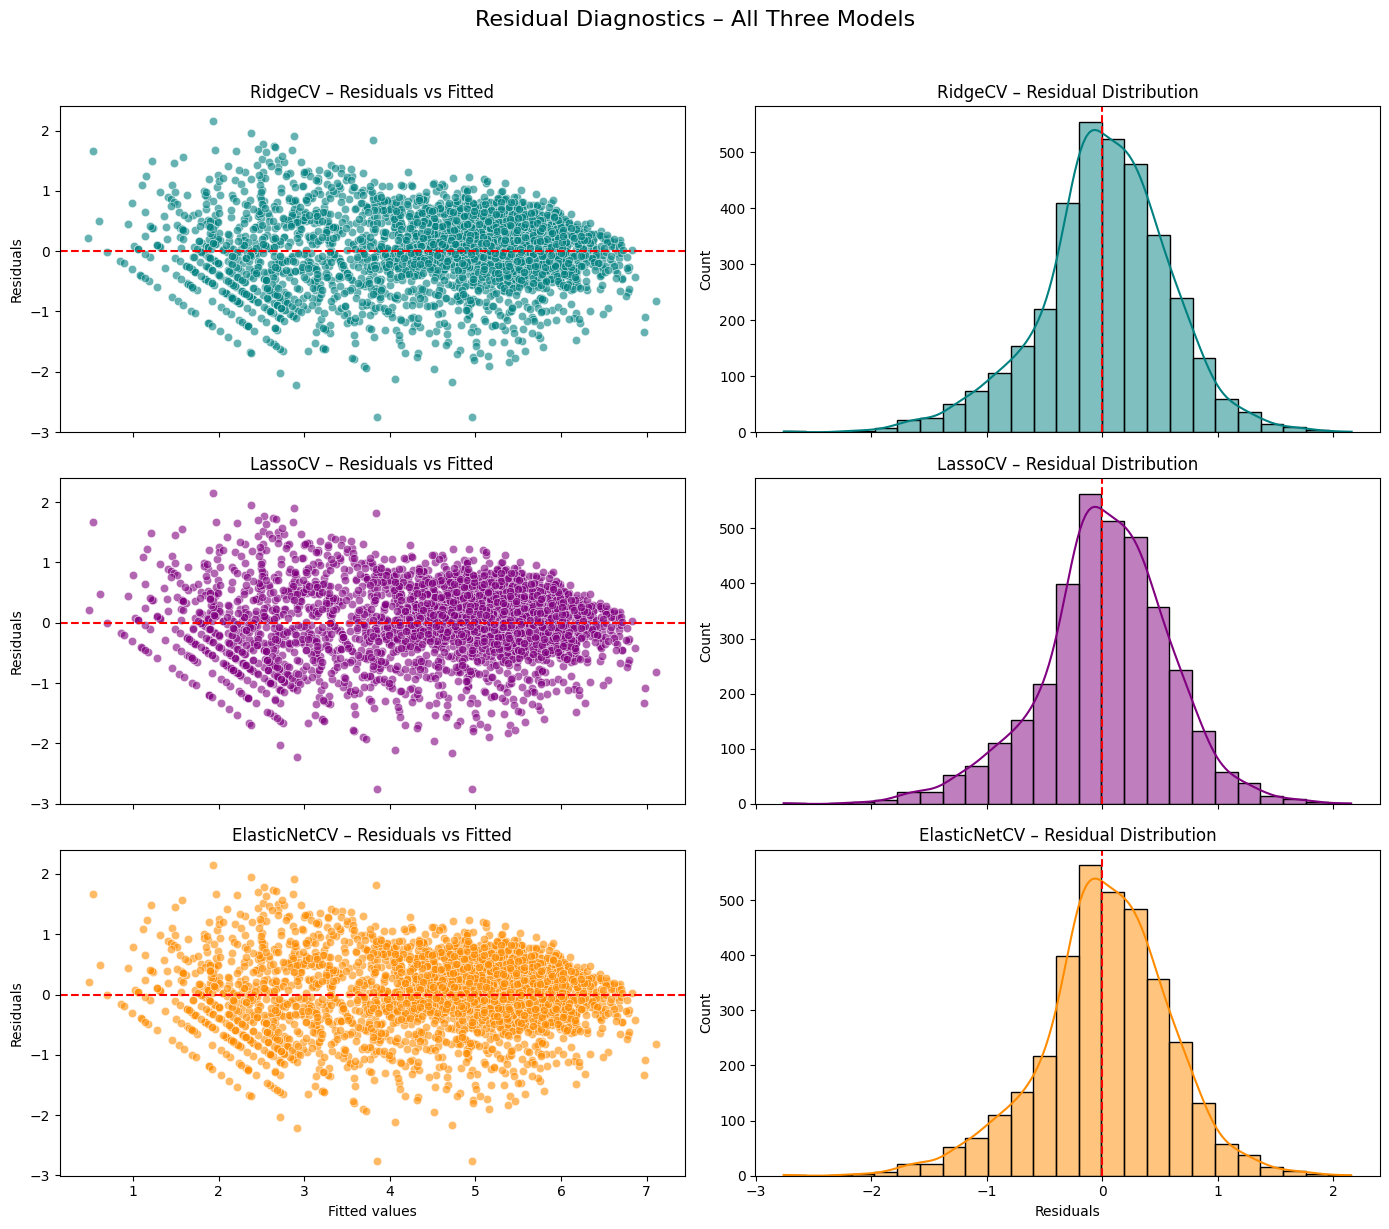

In [88]:
fig, axes = plt.subplots(3, 2, figsize = (14, 12), sharex = 'col')
fig.suptitle("Residual Diagnostics – All Three Models", fontsize = 16, y = 1.02)

for i, (name, model, color) in enumerate([("RidgeCV", ridge_cv, 'teal'), ("LassoCV", lasso_cv, 'purple'), ("ElasticNetCV", elnet_cv, 'darkorange')]):
  preds = model.predict(X_val_final)
  res = y_val - preds

  # Scatter: residuals vs fitted
  sns.scatterplot(x = preds, y = res, ax = axes[i,0], alpha = 0.6, color = color)
  axes[i,0].axhline(0, color = 'red', linestyle = '--')
  axes[i,0].set_title(f"{name} – Residuals vs Fitted")
  axes[i,0].set_xlabel("Fitted values")
  axes[i,0].set_ylabel("Residuals")

  # Histogram + KDE of residuals
  sns.histplot(res, kde = True, ax = axes[i,1], color = color, bins = 25)
  axes[i,1].axvline(0, color = 'red', linestyle = '--')
  axes[i,1].set_title(f"{name} – Residual Distribution")
  axes[i,1].set_xlabel("Residuals")
  axes[i,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [89]:
# Choose the best model (lowest validation RMSE)

models = [("OLS Baseline", rmse_val, r2_score_val), ("RidgeCV", rmse_val_ridge, r2_score_val_ridge),
          ("LassoCV", rmse_val_lasso, r2_score_val_lasso), ("ElasticNetCV", rmse_val_elnet, r2_score_val_elnet)]

# Find model with lowest RMSE
best_name = ""
best_rmse = float('inf')
best_r2 = 0.0

for name, rmse, r2 in models:
  if rmse < best_rmse:
    best_rmse = rmse
    best_r2 = r2
    best_name = name

# Print result
print("\nBest model on validation set:")
print(f"Model: {best_name}")
print(f"RMSE: {best_rmse:.2f}")
print(f"R²: {best_r2:.4f}")


Best model on validation set:
Model: LassoCV
RMSE: 0.57
R²: 0.8370


In [90]:
# Dictionary of all fitted models
model_dict = {"OLS Baseline": ols_model, "RidgeCV": ridge_cv, "LassoCV": lasso_cv, "ElasticNetCV": elnet_cv}

# List of (name, validation RMSE, validation R²)
performance = [("OLS Baseline", rmse_val, r2_score_val), ("RidgeCV", rmse_val_ridge, r2_score_val_ridge),
               ("LassoCV", rmse_val_lasso, r2_score_val_lasso), ("ElasticNetCV", rmse_val_elnet, r2_score_val_elnet)]

# Find the best
best_name = ""
best_rmse = float('inf')
best_r2   = -float('inf')
best_model = None

for name, rmse, r2 in performance:
  if rmse < best_rmse:
    best_rmse = rmse
    best_r2   = r2
    best_name = name
    best_model = model_dict[name]

# Print result
print("\nBest model on validation set:")
print(f"Model: {best_name}")
print(f"RMSE: {best_rmse:.2f}")
print(f"R²: {best_r2:.4f}")

# Safety check
if best_model is None:
    print("ERROR: No model was selected. Check if all RMSE values are defined.")
else:
    print("Best model object is ready for prediction.")


Best model on validation set:
  Model : LassoCV
  RMSE  : 0.57
  R²    : 0.8370
Best model object is ready for prediction.


# **Test Set**

In [91]:
# Final predictions and evaluation on Test Set
print(f"\nSelected final model for predictions: {best_name}")

# Make predictions on the test set
y_test_pred = best_model.predict(X_test_final)

# Calculate metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

# Print results
print(f"MAE for final model: {mae_test:,.2f}")
print(f"MSE for final model: {mse_test:,.2f}")
print(f"RMSE for final model: {rmse_test:,.2f}")
print(f"R² for final model: {r2_test:.4f}")


Selected final model for predictions: LassoCV
MAE for final model: 0.45
MSE for final model: 0.35
RMSE for final model: 0.59
R² for final model: 0.8208
